vx max:  1.3152457
vy max:  0.9688884
vtheta max:  1.6145242
eevx max:  1.3243196
eevy max:  1.6207142
eevz max:  1.1249695
eervx max:  2.046181
eervy max:  3.693052
eervz max:  2.3627827


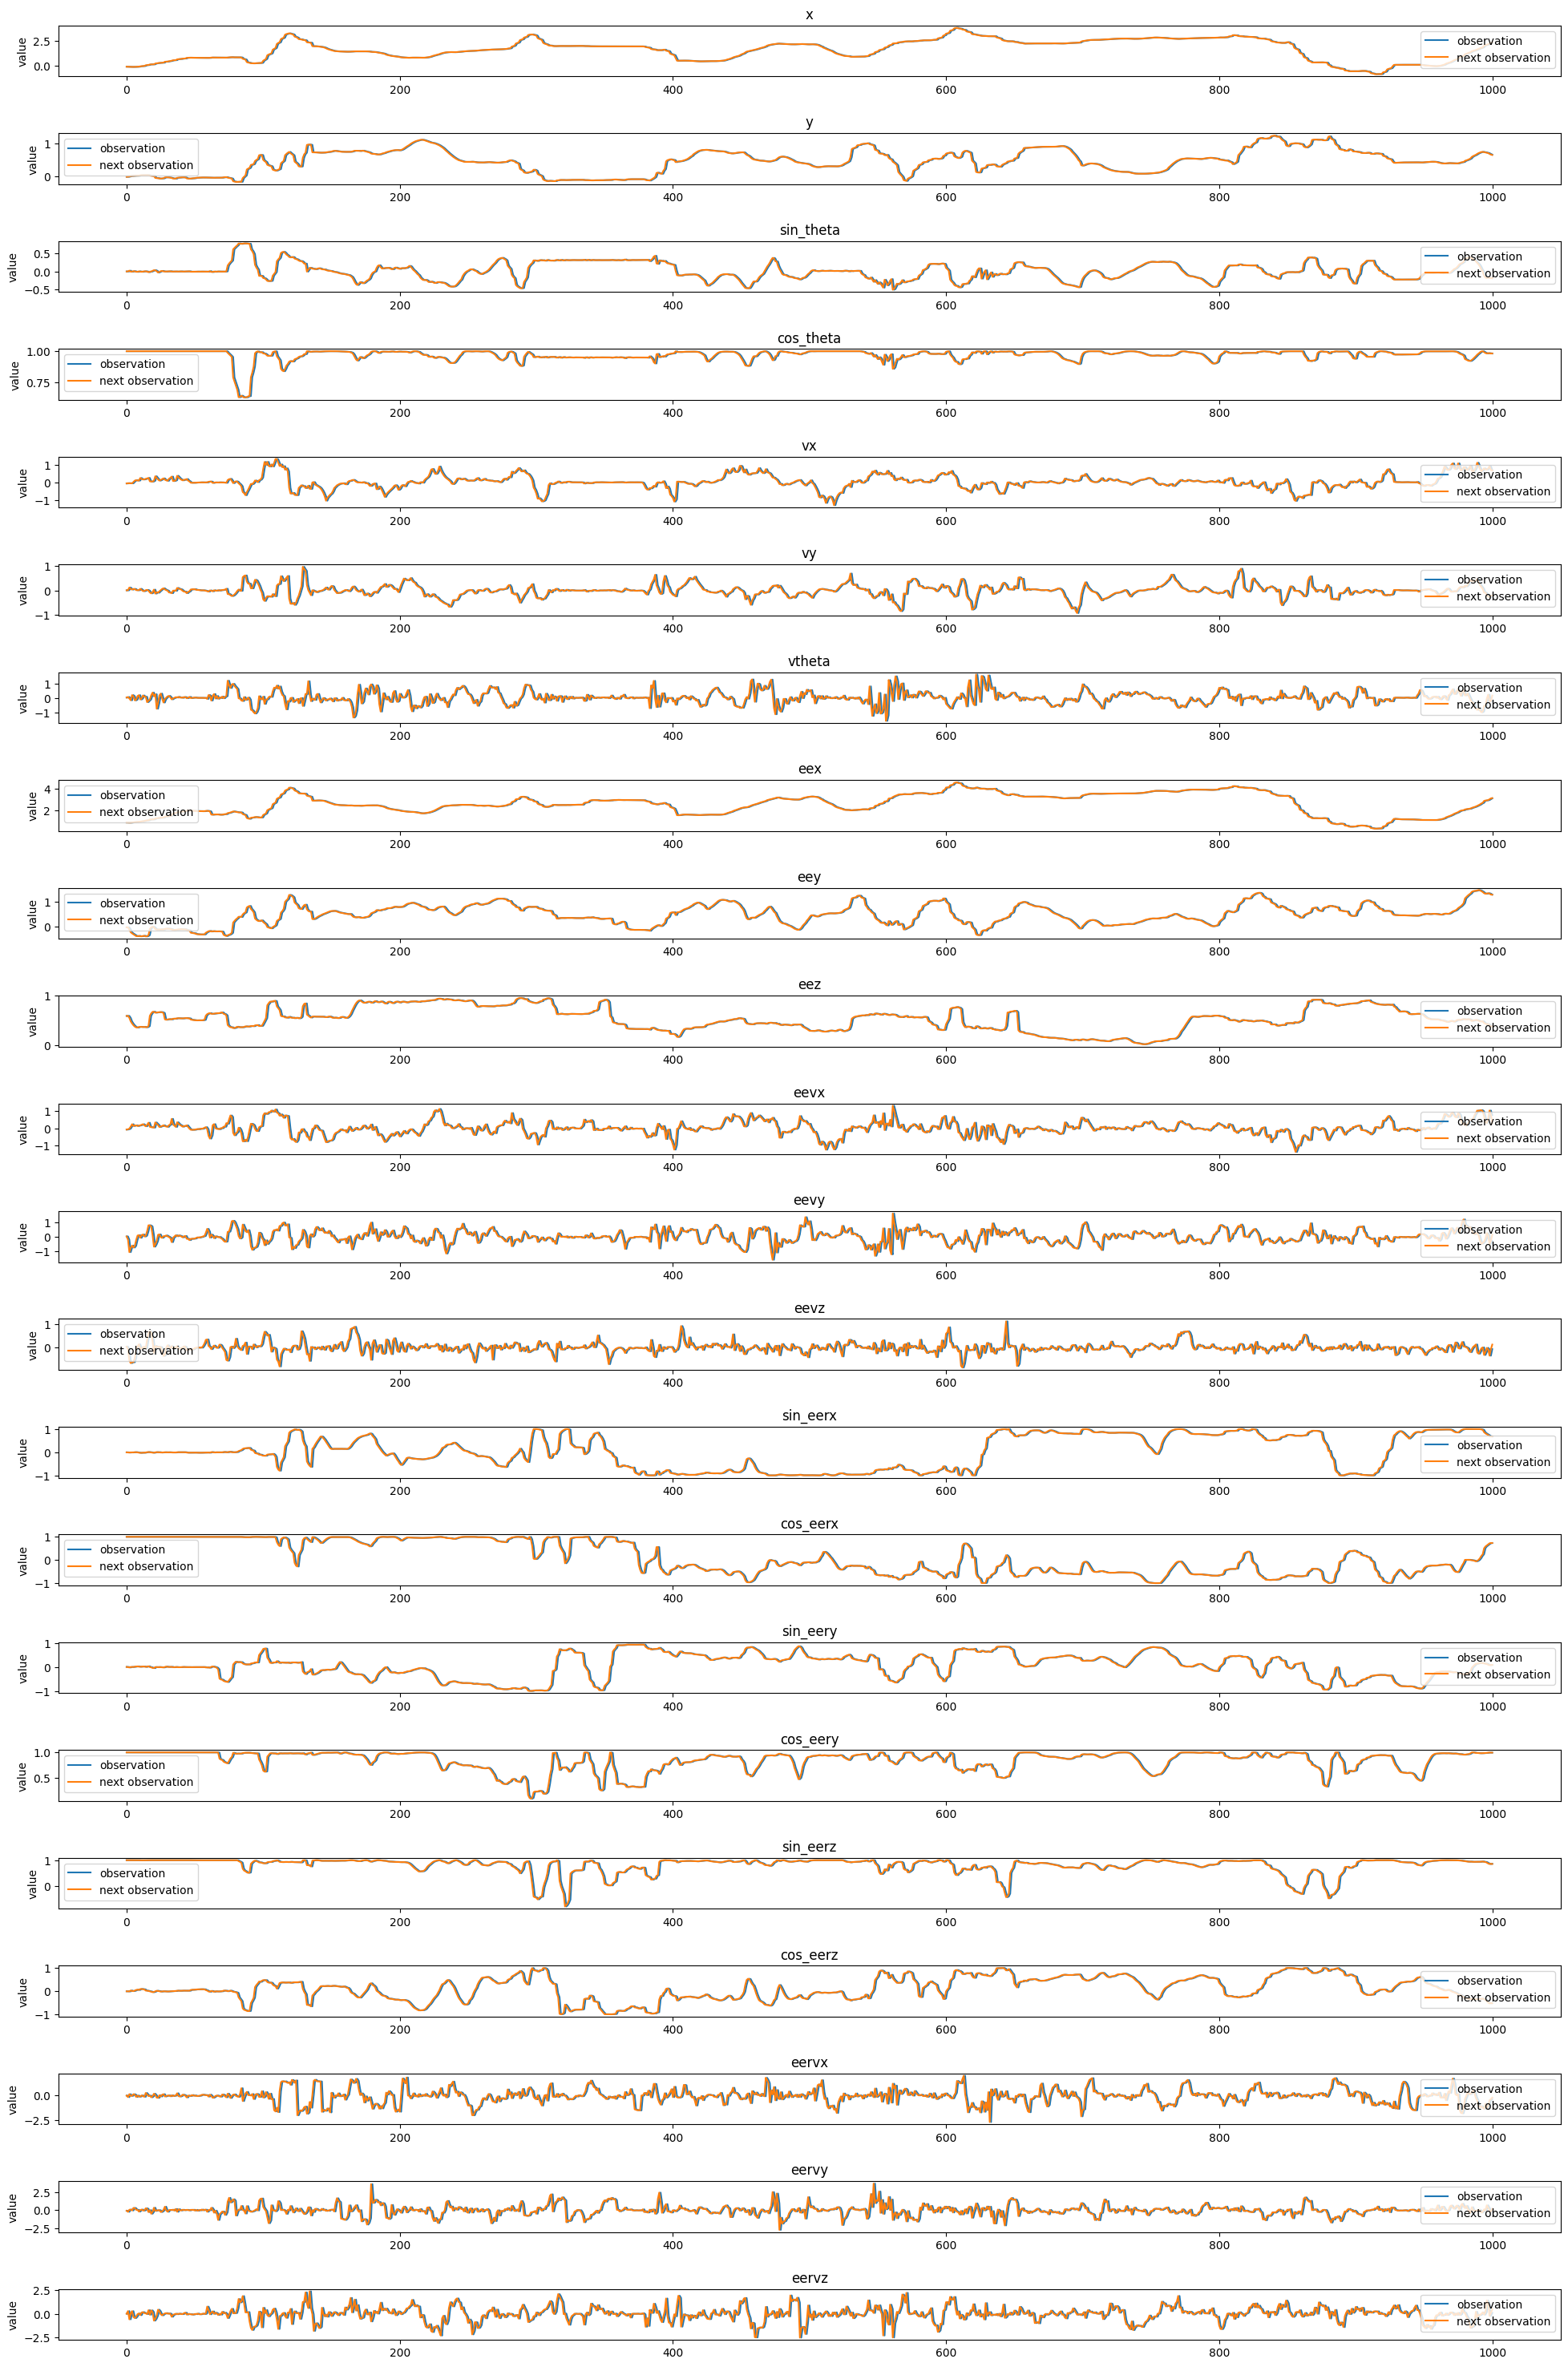

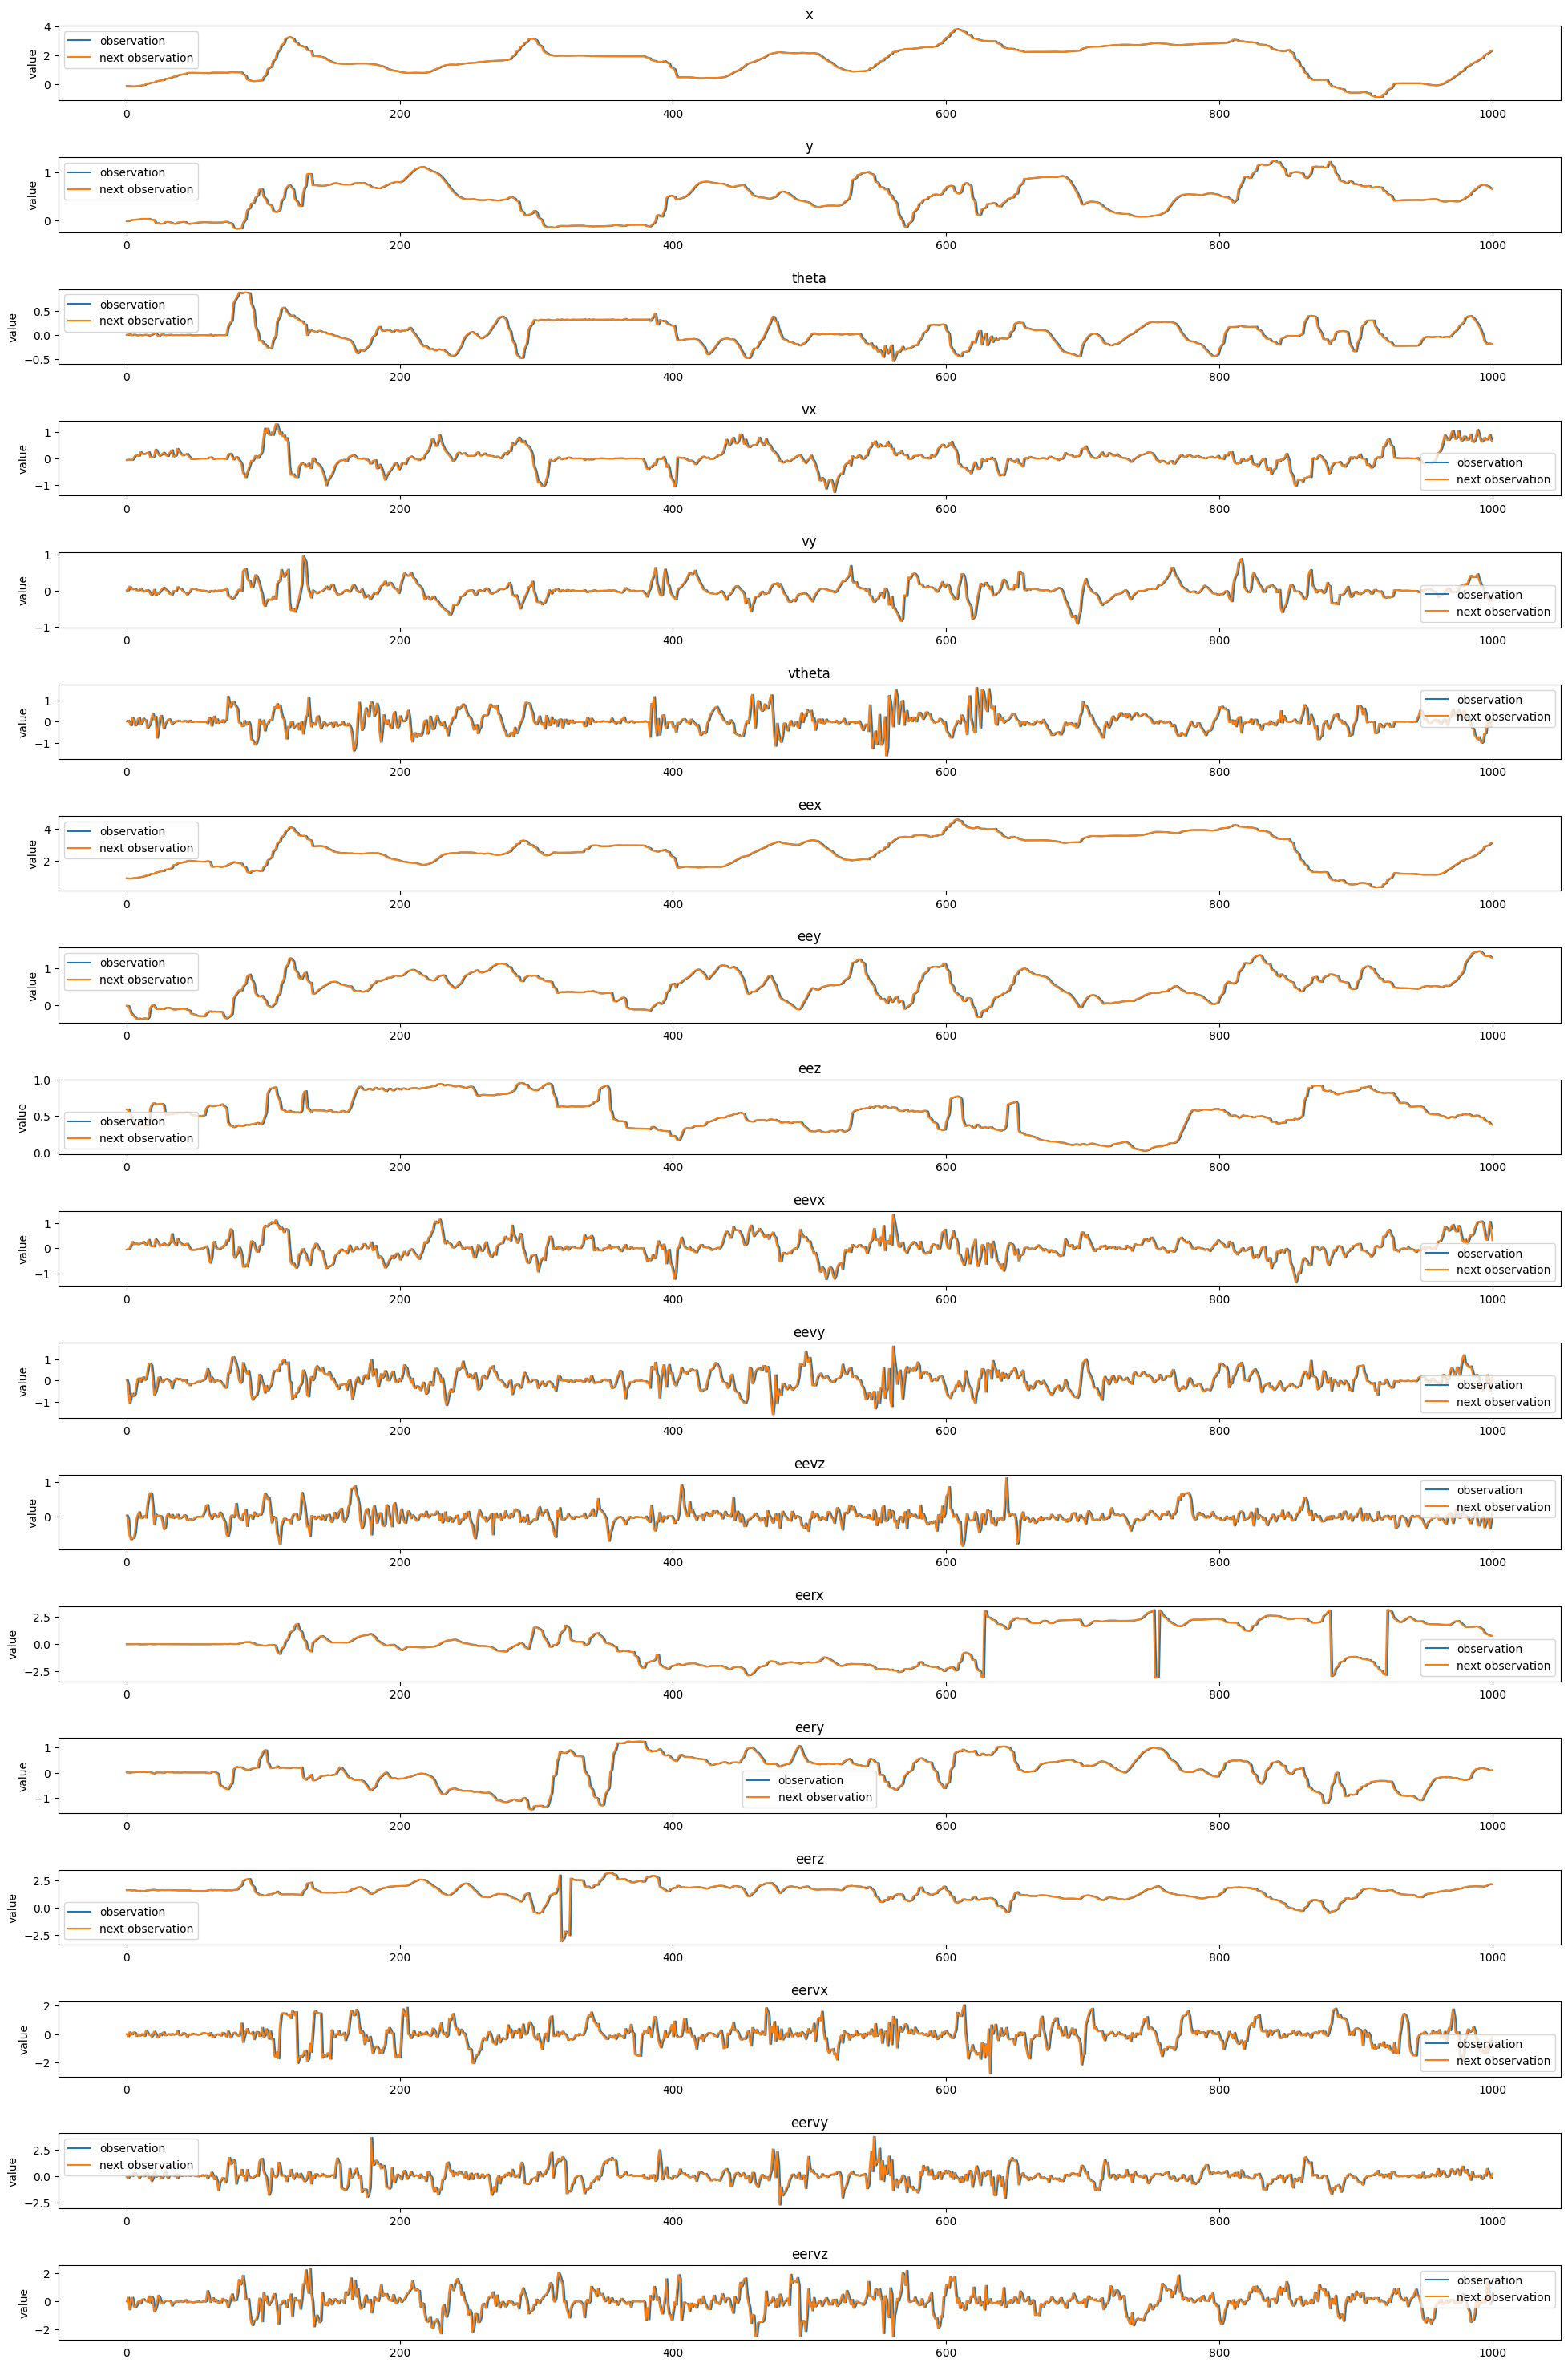

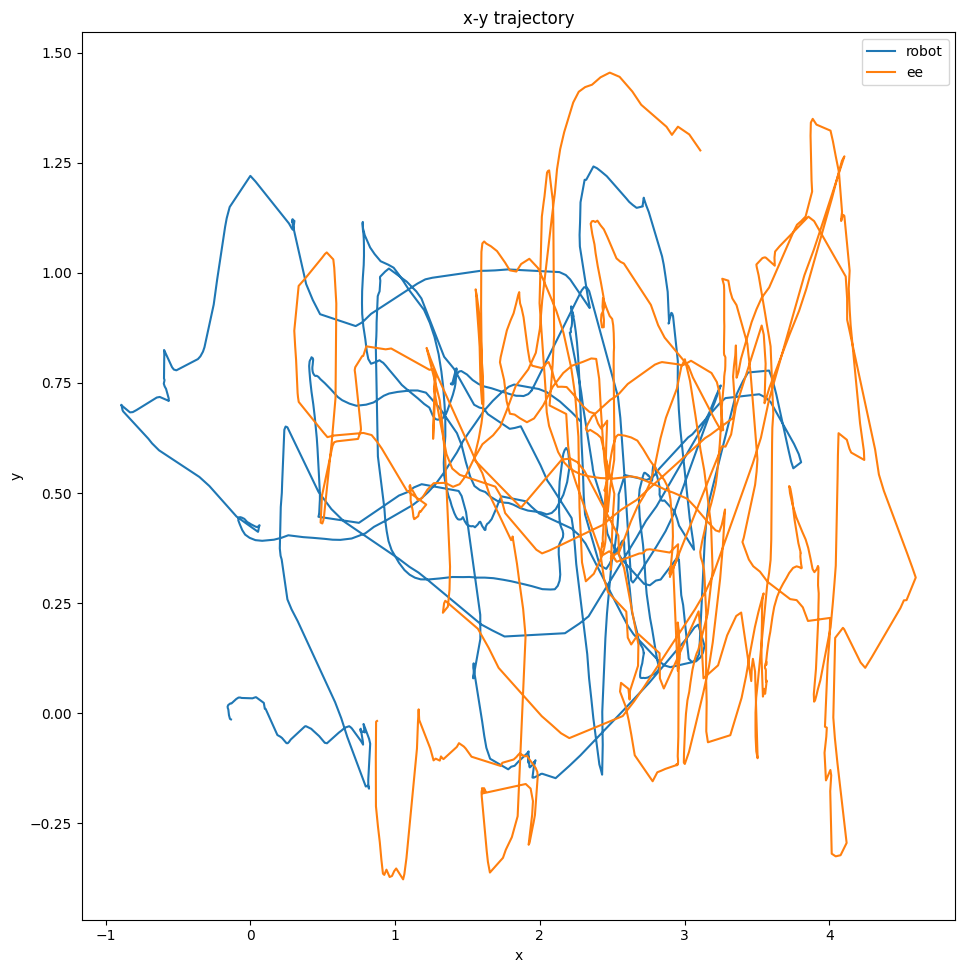

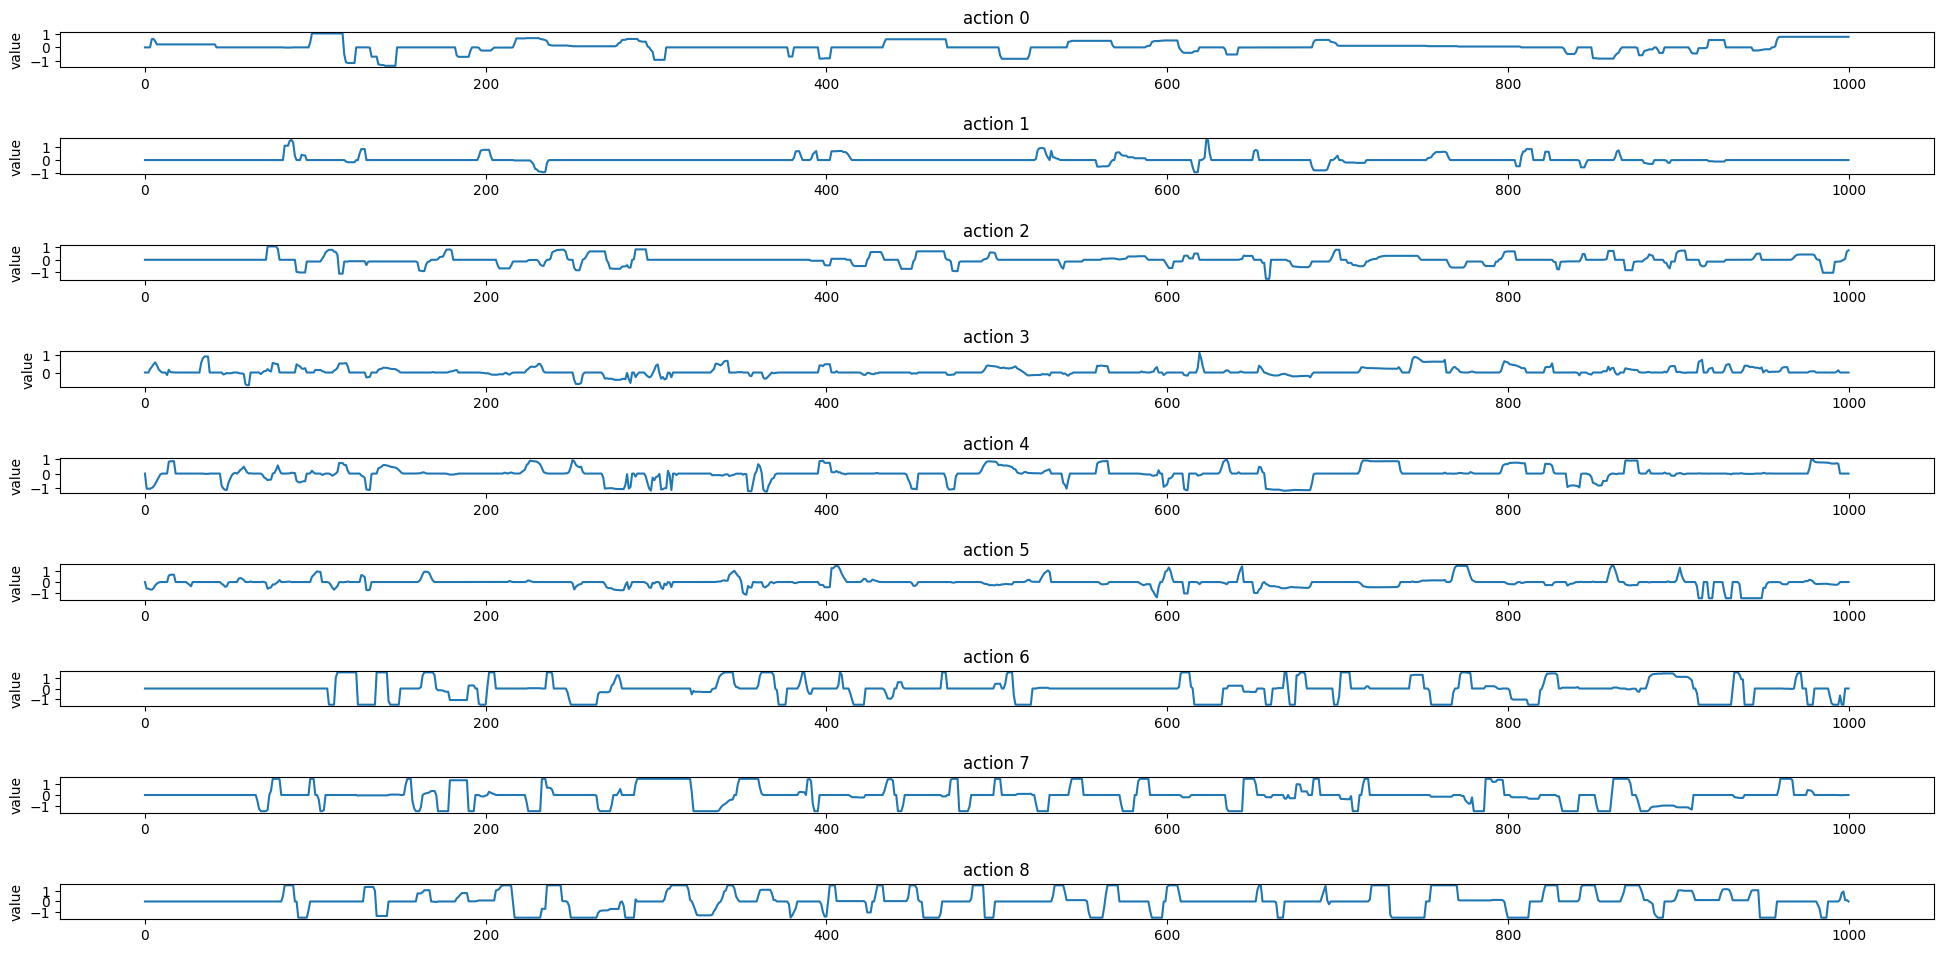

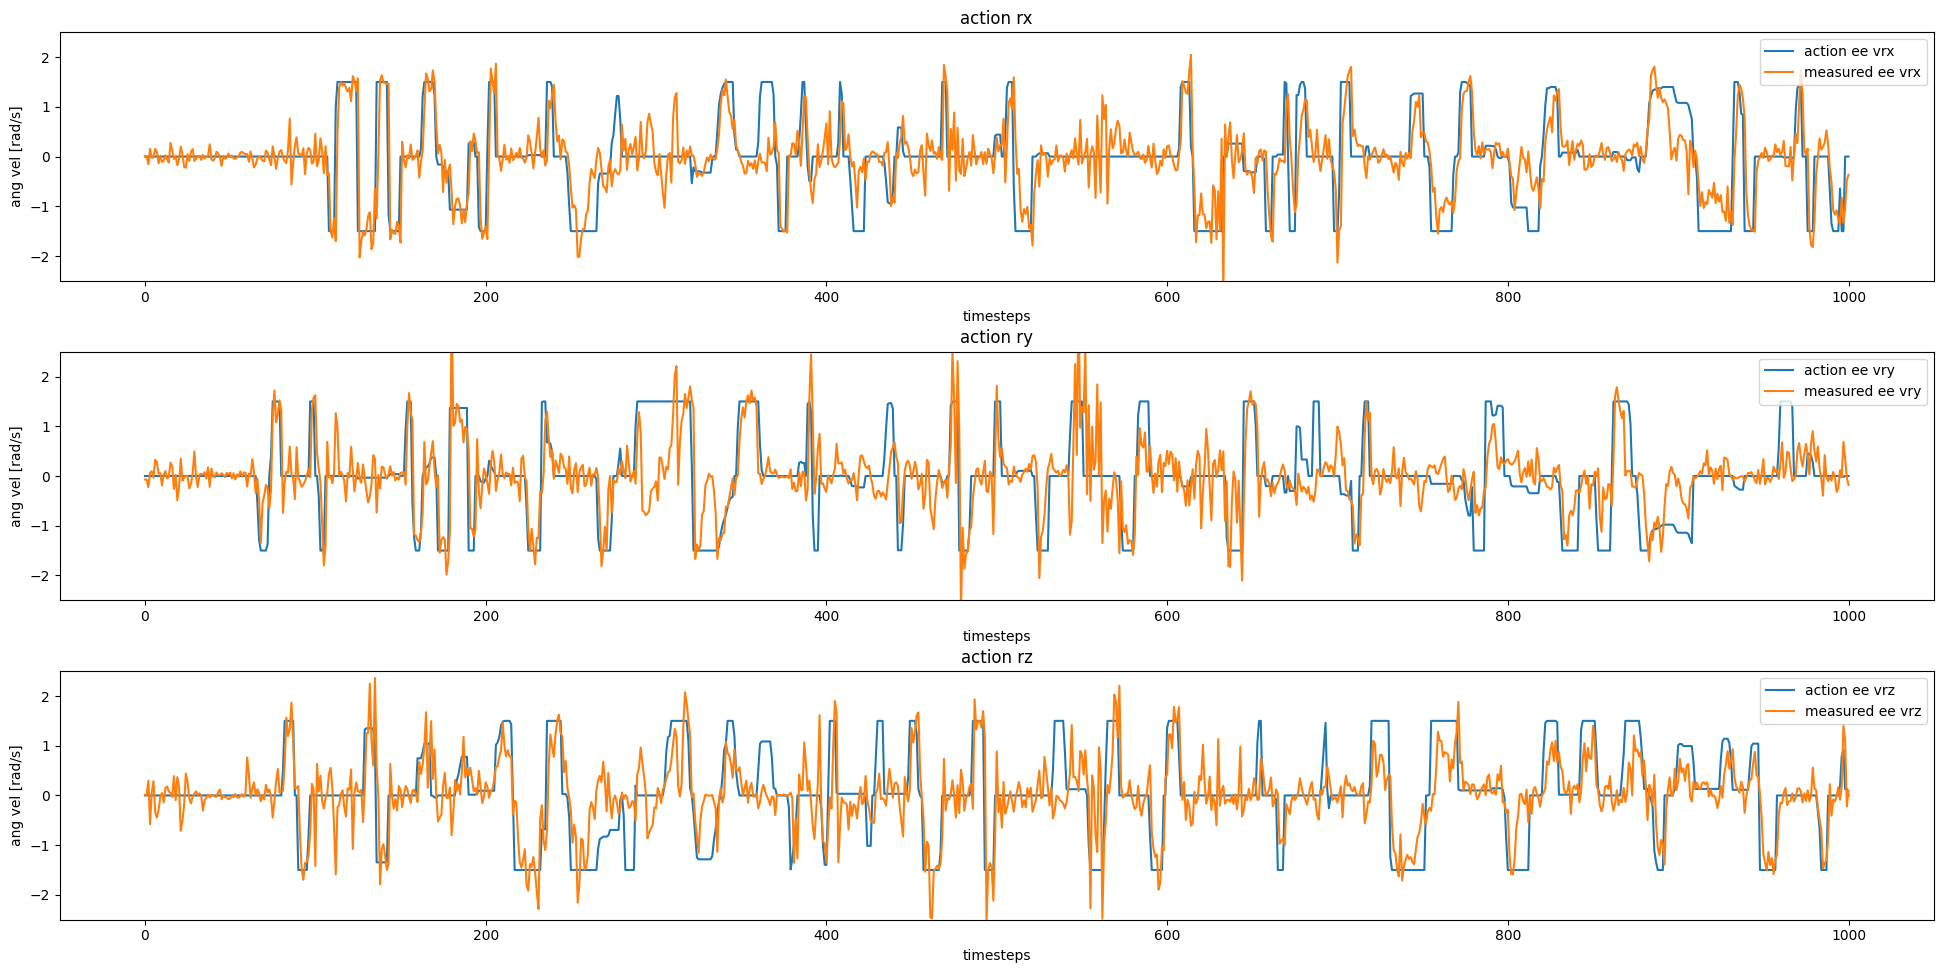

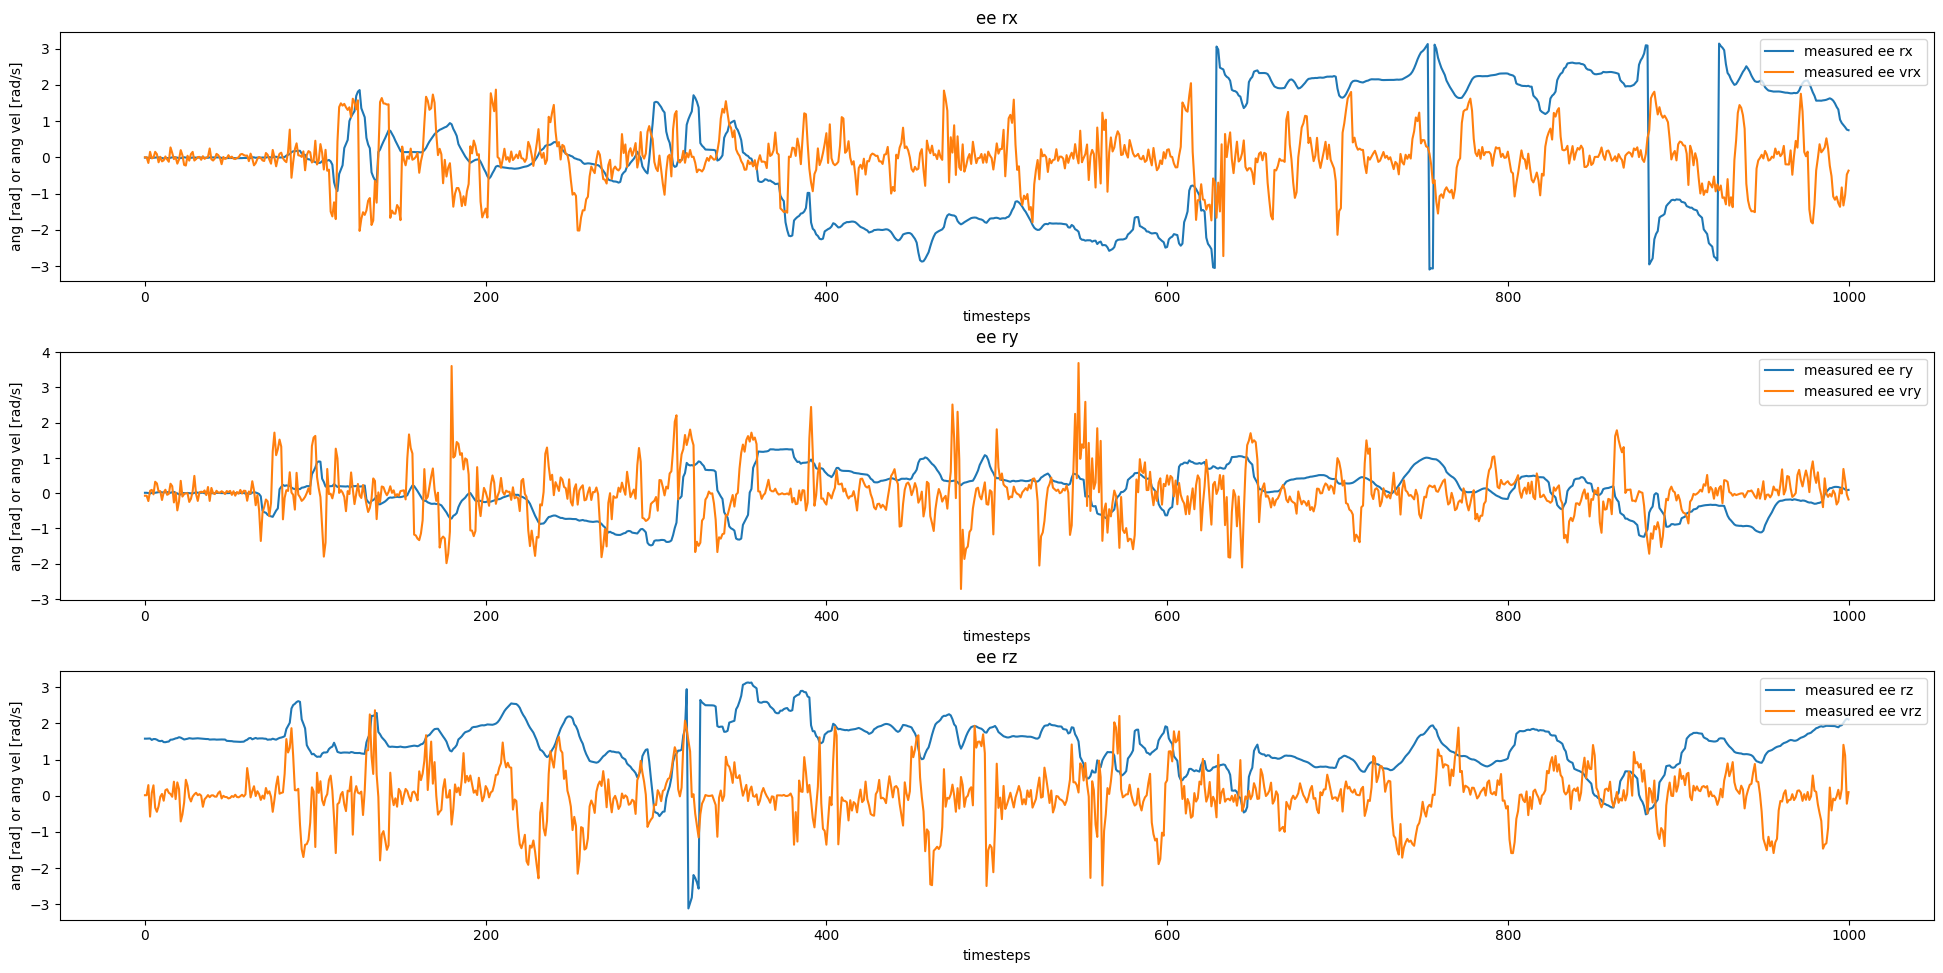

: 

In [ ]:
"""Analyse data collected on real robot"""

import os
import pickle
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

v0 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v0.pickle"
v1 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v1.pickle"
v2 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v2.pickle"
v3 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v3.pickle"
v4 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v4.pickle"

v5 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v0.pickle"
v6 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v1.pickle"
v7 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v2.pickle"
v8 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v3.pickle"
v9 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v4.pickle"
v10 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v5.pickle"

v00_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v0.pickle"
v01_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v1.pickle"
v02_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v2.pickle"
v03_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v3.pickle"
v04_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v4.pickle"
v05_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v5.pickle"
v06_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v6.pickle"
v07_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v7.pickle"
v08_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v8.pickle"

v00_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v0.pickle"
v01_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v1.pickle"
v02_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v2.pickle"
v03_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v3.pickle"
v04_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v4.pickle"
v05_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v5.pickle"
v06_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v6.pickle"
v07_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v7.pickle"
v08_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v8.pickle"

vrx_00 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-165528_vrx_testing/brax_transitions.pickle"
vrx_01 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-165656_vrx_testing_01/brax_transitions.pickle"
vrx_02 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-170634_vrx_testing_02/brax_transitions.pickle"
vrx_03 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-171728_vrx_testing_03/brax_transitions.pickle"

vtest = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee/brax_transitions_v2.pickle"

voritest = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee/brax_transitions_ee_ori_testing_odom_v0.pickle"

vori_v0 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241115-093918_ee_ori_traj_v0/brax_transitions.pickle"

file_names = [v18]

v0_ee_benchmark = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee_v1/brax_transitions_ee_ori_benchmark_odom_v0.pickle"
v1_ee_benchmark = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee_v1/brax_transitions_ee_ori_benchmark_odom_v1.pickle"
v0_ee_long = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee_v1/brax_transitions_ee_ori_long_odom_v0.pickle"

file_names = [v1_ee_benchmark]



# Define the state label dictionaries
state_label_dict = {
    0: "x",
    1: "y",
    2: "sin_theta",
    3: "cos_theta",
    4: "vx",
    5: "vy",
    6: "vtheta",
    7: "eex",
    8: "eey",
    9: "eez",
    10: "eevx",
    11: "eevy",
    12: "eevz",
    13: "sin_eerx",
    14: "cos_eerx",
    15: "sin_eery",
    16: "cos_eery",
    17: "sin_eerz",
    18: "cos_eerz",
    19: "eervx",
    20: "eervy",
    21: "eervz"
}

state_label_dict_cleaned = {
    0: "x",
    1: "y",
    2: "theta",
    3: "vx",
    4: "vy",
    5: "vtheta",
    6: "eex",
    7: "eey",
    8: "eez",
    9: "eevx",
    10: "eevy",
    11: "eevz",
    12: "eerx",
    13: "eery",
    14: "eerz",
    15: "eervx",
    16: "eervy",
    17: "eervz"
}

def load_data(file_names):
    data = []
    for file_name in file_names:
        with open(file_name, "rb") as f:
            data += pickle.load(f)
    return data

def transform_state_omega(states):
    sin_ee_rx = states[..., 13]
    cos_ee_rx = states[..., 14]
    sin_ee_ry = states[..., 15]
    cos_ee_ry = states[..., 16]
    sin_ee_rz = states[..., 17]
    cos_ee_rz = states[..., 18]
    roll = np.arctan2(sin_ee_rx, cos_ee_rx)
    pitch = np.arctan2(sin_ee_ry, cos_ee_ry)
    yaw = np.arctan2(sin_ee_rz, cos_ee_rz)
    rotations = R.from_euler('xyz', np.column_stack((roll, pitch, yaw)))
    omega_global = states[..., 19:22]
    omega_hand = rotations.inv().apply(omega_global)
    transformed_states = states.copy()
    transformed_states[..., 19:22] = omega_hand
    return transformed_states

data = load_data(file_names)

observations = np.array([d.observation for d in data])
actions = np.array([d.action for d in data])
next_observations = np.array([d.next_observation for d in data])


# next_observations = transform_state_omega(next_observations)
# observations = transform_state_omega(observations)

# cut at 200
# observations = observations[0:100]
# actions = actions[0:100]
# next_observations = next_observations[0:100]



plt.show()

print("vx max: ", np.max(observations[:, 4]))
print("vy max: ", np.max(observations[:, 5]))
print("vtheta max: ", np.max(observations[:, 6]))
print("eevx max: ", np.max(observations[:, 10]))
print("eevy max: ", np.max(observations[:, 11]))
print("eevz max: ", np.max(observations[:, 12]))
print("eervx max: ", np.max(observations[:, 19]))
print("eervy max: ", np.max(observations[:, 20]))
print("eervz max: ", np.max(observations[:, 21]))

n_plots = len(state_label_dict_cleaned)

# decode observations
theta = np.arctan2(observations[:, 2], observations[:, 3])
ee_rx = np.arctan2(observations[:, 13], observations[:, 14])
ee_ry = np.arctan2(observations[:, 15], observations[:, 16])
ee_rz = np.arctan2(observations[:, 17], observations[:, 18])

obsertvations_cleaned = np.zeros((observations.shape[0], n_plots))
obsertvations_cleaned[:, 0] = observations[:, 0]
obsertvations_cleaned[:, 1] = observations[:, 1]
obsertvations_cleaned[:, 2] = theta
obsertvations_cleaned[:, 3] = observations[:, 4]
obsertvations_cleaned[:, 4] = observations[:, 5]
obsertvations_cleaned[:, 5] = observations[:, 6]
obsertvations_cleaned[:, 6] = observations[:, 7]
obsertvations_cleaned[:, 7] = observations[:, 8]
obsertvations_cleaned[:, 8] = observations[:, 9]
obsertvations_cleaned[:, 9] = observations[:, 10]
obsertvations_cleaned[:, 10] = observations[:, 11]
obsertvations_cleaned[:, 11] = observations[:, 12]
obsertvations_cleaned[:, 12] = ee_rx
obsertvations_cleaned[:, 13] = ee_ry
obsertvations_cleaned[:, 14] = ee_rz
obsertvations_cleaned[:, 15] = observations[:, 19]
obsertvations_cleaned[:, 16] = observations[:, 20]
obsertvations_cleaned[:, 17] = observations[:, 21]

# decode next_observations
theta_next = np.arctan2(next_observations[:, 2], next_observations[:, 3])
ee_rx_next = np.arctan2(next_observations[:, 13], next_observations[:, 14])
ee_ry_next = np.arctan2(next_observations[:, 15], next_observations[:, 16])
ee_rz_next = np.arctan2(next_observations[:, 17], next_observations[:, 18])

next_obsertvations_cleaned = np.zeros((next_observations.shape[0], n_plots))
next_obsertvations_cleaned[:, 0] = next_observations[:, 0]
next_obsertvations_cleaned[:, 1] = next_observations[:, 1]
next_obsertvations_cleaned[:, 2] = theta_next
next_obsertvations_cleaned[:, 3] = next_observations[:, 4]
next_obsertvations_cleaned[:, 4] = next_observations[:, 5]
next_obsertvations_cleaned[:, 5] = next_observations[:, 6]
next_obsertvations_cleaned[:, 6] = next_observations[:, 7]
next_obsertvations_cleaned[:, 7] = next_observations[:, 8]
next_obsertvations_cleaned[:, 8] = next_observations[:, 9]
next_obsertvations_cleaned[:, 9] = next_observations[:, 10]
next_obsertvations_cleaned[:, 10] = next_observations[:, 11]
next_obsertvations_cleaned[:, 11] = next_observations[:, 12]
next_obsertvations_cleaned[:, 12] = ee_rx_next
next_obsertvations_cleaned[:, 13] = ee_ry_next
next_obsertvations_cleaned[:, 14] = ee_rz_next
next_obsertvations_cleaned[:, 15] = next_observations[:, 19]
next_obsertvations_cleaned[:, 16] = next_observations[:, 20]
next_obsertvations_cleaned[:, 17] = next_observations[:, 21]

# plot everything

# plot uncleaned
fig, axs = plt.subplots(len(state_label_dict), 1, figsize=(20, 30))
# add some space between subplots
fig.tight_layout(pad=3.0)

for i in range(len(state_label_dict)):
    axs[i].plot(observations[:, i], label="observation")
    axs[i].plot(next_observations[:, i], label="next observation")
    axs[i].set_title(state_label_dict[i])
    axs[i].set_ylabel("value")
    axs[i].legend()

plt.show()


fig, axs = plt.subplots(n_plots, 1, figsize=(20, 30))
# add some space between subplots
fig.tight_layout(pad=3.0)

for i in range(n_plots):
    axs[i].plot(obsertvations_cleaned[:, i], label="observation")
    axs[i].plot(next_obsertvations_cleaned[:, i], label="next observation")

    axs[i].set_title(state_label_dict_cleaned[i])
    axs[i].set_ylabel("value")
    axs[i].legend()

plt.show()

# plot x,y ee_x, ee_y 2d trajectory
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)

axs.plot(obsertvations_cleaned[:, 0], obsertvations_cleaned[:, 1], label="robot")
axs.plot(obsertvations_cleaned[:, 6], obsertvations_cleaned[:, 7], label="ee")
axs.set_title("x-y trajectory")
axs.set_xlabel("x")
axs.set_ylabel("y")
axs.legend()
plt.show()


# plot actions
actions = np.array(actions)
fig, axs = plt.subplots(9, 1, figsize=(20, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)

for i in range(9):
    axs[i].plot(actions[:, i])
    axs[i].set_title("action " + str(i))
    axs[i].set_ylabel("value")


# plot ee vrx, ee vry, ee vrz on top of actions
fig, axs = plt.subplots(3, 1, figsize=(20, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)
labels = ["rx", "ry", "rz"]
for i in range(3):
    axs[i].plot(actions[:, i+6], label=f"action ee v{labels[i]}")
    axs[i].plot(obsertvations_cleaned[:, 15+i], label=f"measured ee v{labels[i]}")
    axs[i].set_title("action " + labels[i])
    axs[i].set_ylabel("ang vel [rad/s]")
    axs[i].set_xlabel("timesteps")
    # make legend always in top right
    axs[i].legend(loc='upper right')    
    # scale y from 0 to 1
    axs[i].set_ylim(-2.5, 2.5)
plt.show()

# plot ee rx, ee ry, ee rz on top of ee vrx, ee vry, ee vrz
fig, axs = plt.subplots(3, 1, figsize=(20, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)
labels = ["rx", "ry", "rz"]
for i in range(3):
    axs[i].plot(obsertvations_cleaned[:, 12+i], label=f"measured ee {labels[i]}")
    axs[i].plot(obsertvations_cleaned[:, 15+i], label=f"measured ee v{labels[i]}")
    axs[i].set_title("ee " + labels[i])
    axs[i].set_ylabel("ang [rad] or ang vel [rad/s]")
    axs[i].set_xlabel("timesteps")
    # make legend always in top right
    axs[i].legend(loc='upper right')
plt.show()



import plotly.graph_objects as go
from scipy.spatial.transform import Rotation as R
import numpy as np

# Extract positions
eex = obsertvations_cleaned[:, 6]
eey = obsertvations_cleaned[:, 7]
eez = obsertvations_cleaned[:, 8]

# Extract orientations
ee_rx = obsertvations_cleaned[:, 12]
ee_ry = obsertvations_cleaned[:, 13]
ee_rz = obsertvations_cleaned[:, 14]

# Stack angles
angles = np.column_stack((ee_rx, ee_ry, ee_rz))

# Create rotations
rotations = R.from_euler('xyz', angles)

# Reference vector
ref_vec = np.array([0.5, 0, 0])  # Adjust length as needed

# Apply rotations to reference vector
vectors = rotations.apply(ref_vec)

# Plot end effector path
path_trace = go.Scatter3d(
    x=eex,
    y=eey,
    z=eez,
    mode='lines',
    name='End Effector Path',
    line=dict(color='blue')
)

# Plot orientation vectors at intervals
n = 5  # Plot every nth vector
vector_traces = []

for i in range(0, len(eex), n):
    x_start = eex[i]
    y_start = eey[i]
    z_start = eez[i]
    
    x_end = eex[i] + vectors[i, 0]
    y_end = eey[i] + vectors[i, 1]
    z_end = eez[i] + vectors[i, 2]
    
    vector_trace = go.Scatter3d(
        x=[x_start, x_end],
        y=[y_start, y_end],
        z=[z_start, z_end],
        mode='lines',
        line=dict(color='red', width=5),
        showlegend=False
    )
    vector_traces.append(vector_trace)

# Combine traces
data = [path_trace] + vector_traces

# Layout
layout = go.Layout(
    title='End Effector Positions and Orientations',
    scene=dict(
        xaxis=dict(
            title='X Position',
            range=[-2, 10]
        ),
        yaxis=dict(
            title='Y Position',
            range=[-2, 2]
        ),
        zaxis=dict(
            title='Z Position',
            range=[0, 2]
        )
    ),
    width=1400,
    height=900
)

# Figure
fig = go.Figure(data=data, layout=layout)

# Show plot
fig.show()

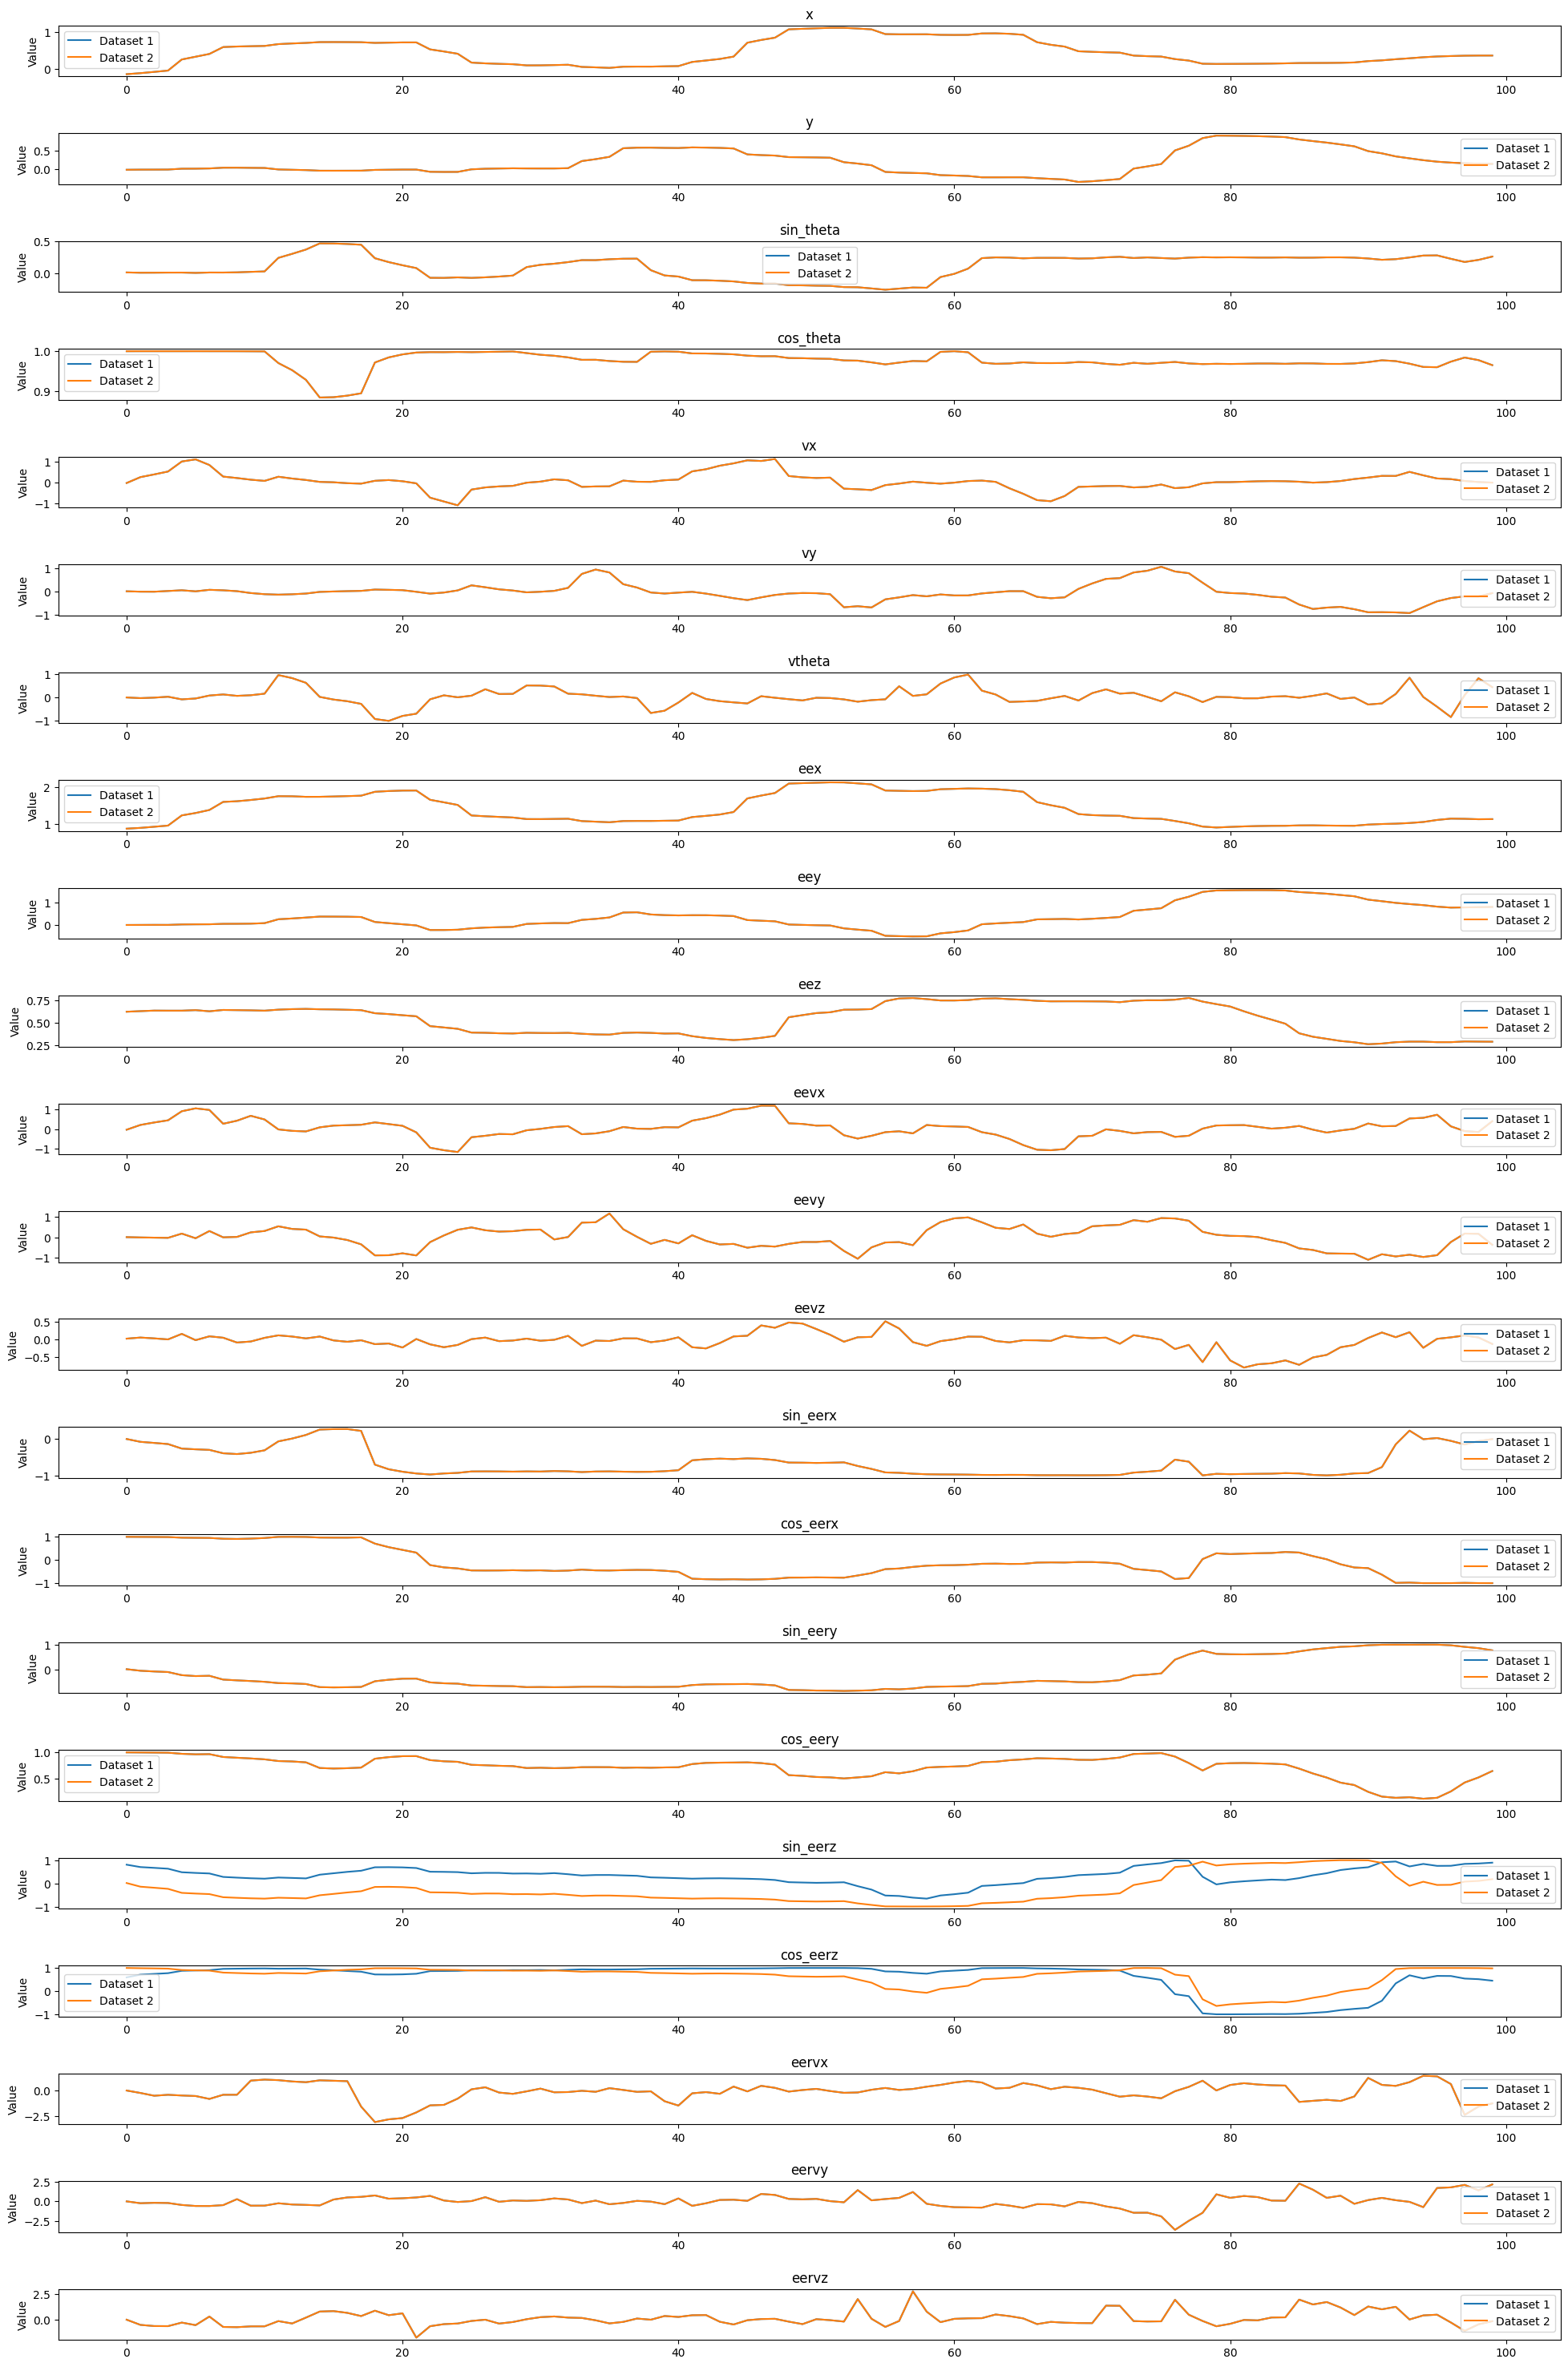

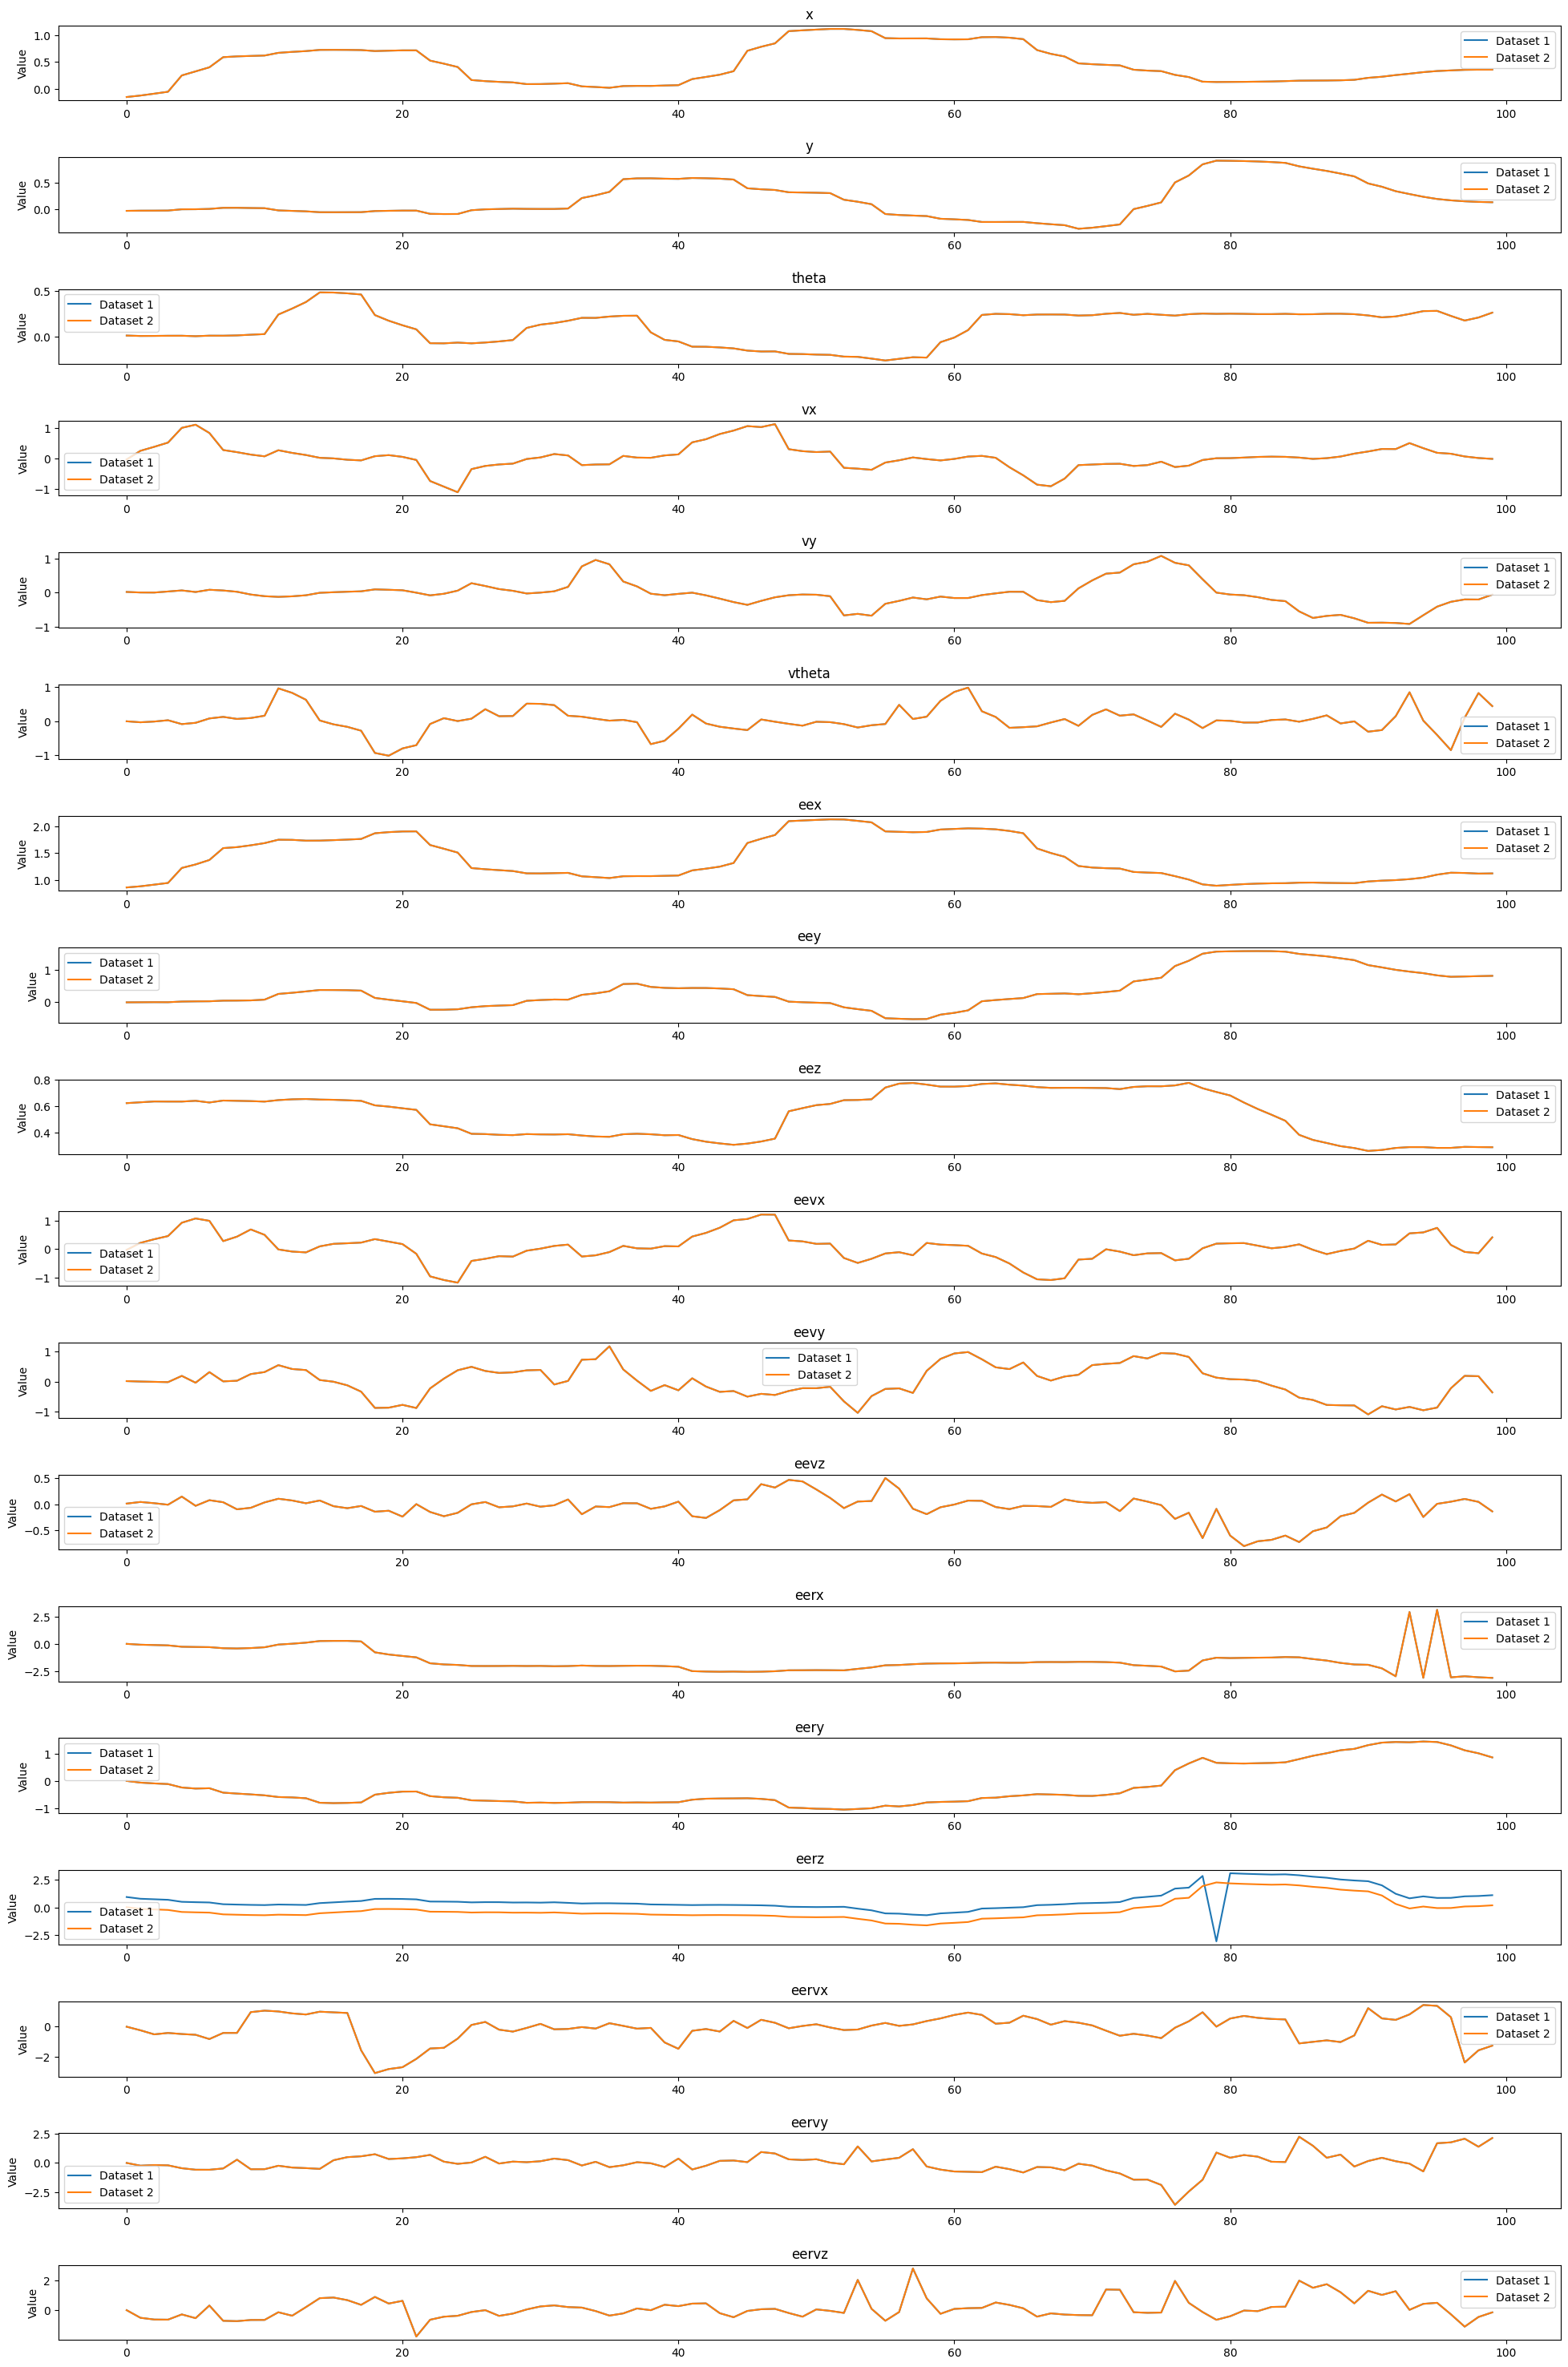

In [25]:
"""Analyse data collected on real robot"""

import os
import pickle
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

v0 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v0.pickle"
v1 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v1.pickle"
v2 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v2.pickle"
v3 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v3.pickle"
v4 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v0/brax_transitions_v4.pickle"

v5 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v0.pickle"
v6 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v1.pickle"
v7 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v2.pickle"
v8 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v3.pickle"
v9 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v4.pickle"
v10 = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v1/brax_transitions_v5.pickle"

v00_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v0.pickle"
v01_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v1.pickle"
v02_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v2.pickle"
v03_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v3.pickle"
v04_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v4.pickle"
v05_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v5.pickle"
v06_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v6.pickle"
v07_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v7.pickle"
v08_odom = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_v2/brax_transitions_odom_v8.pickle"

v00_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v0.pickle"
v01_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v1.pickle"
v02_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v2.pickle"
v03_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v3.pickle"
v04_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v4.pickle"
v05_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v5.pickle"
v06_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v6.pickle"
v07_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v7.pickle"
v08_vision = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/recordings_spot_ee_vision_v2/brax_transitions_v8.pickle"

vrx_00 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-165528_vrx_testing/brax_transitions.pickle"
vrx_01 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-165656_vrx_testing_01/brax_transitions.pickle"
vrx_02 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-170634_vrx_testing_02/brax_transitions.pickle"
vrx_03 = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241105-171728_vrx_testing_03/brax_transitions.pickle"

vtest = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee/brax_transitions_v2.pickle"



# Define the state label dictionaries
state_label_dict = {
    0: "x",
    1: "y",
    2: "sin_theta",
    3: "cos_theta",
    4: "vx",
    5: "vy",
    6: "vtheta",
    7: "eex",
    8: "eey",
    9: "eez",
    10: "eevx",
    11: "eevy",
    12: "eevz",
    13: "sin_eerx",
    14: "cos_eerx",
    15: "sin_eery",
    16: "cos_eery",
    17: "sin_eerz",
    18: "cos_eerz",
    19: "eervx",
    20: "eervy",
    21: "eervz"
}

state_label_dict_cleaned = {
    0: "x",
    1: "y",
    2: "theta",
    3: "vx",
    4: "vy",
    5: "vtheta",
    6: "eex",
    7: "eey",
    8: "eez",
    9: "eevx",
    10: "eevy",
    11: "eevz",
    12: "eerx",
    13: "eery",
    14: "eerz",
    15: "eervx",
    16: "eervy",
    17: "eervz"
}

def load_data(file_names):
    data = []
    for file_name in file_names:
        with open(file_name, "rb") as f:
            data += pickle.load(f)
    return data

def transform_state_omega(states):
    sin_ee_rx = states[..., 13]
    cos_ee_rx = states[..., 14]
    sin_ee_ry = states[..., 15]
    cos_ee_ry = states[..., 16]
    sin_ee_rz = states[..., 17]
    cos_ee_rz = states[..., 18]
    roll = np.arctan2(sin_ee_rx, cos_ee_rx)
    pitch = np.arctan2(sin_ee_ry, cos_ee_ry)
    yaw = np.arctan2(sin_ee_rz, cos_ee_rz)
    rotations = R.from_euler('xyz', np.column_stack((roll, pitch, yaw)))
    omega_global = states[..., 19:22]
    omega_hand = rotations.inv().apply(omega_global)
    transformed_states = states.copy()
    transformed_states[..., 19:22] = omega_hand
    return transformed_states

def clean_observations(observations, theta, ee_rx, ee_ry, ee_rz):
    n_plots = len(state_label_dict_cleaned)
    cleaned_obs = np.zeros((observations.shape[0], n_plots))
    cleaned_obs[:, 0] = observations[:, 0]  # x
    cleaned_obs[:, 1] = observations[:, 1]  # y
    cleaned_obs[:, 2] = theta               # theta
    cleaned_obs[:, 3] = observations[:, 4]  # vx
    cleaned_obs[:, 4] = observations[:, 5]  # vy
    cleaned_obs[:, 5] = observations[:, 6]  # vtheta
    cleaned_obs[:, 6] = observations[:, 7]  # eex
    cleaned_obs[:, 7] = observations[:, 8]  # eey
    cleaned_obs[:, 8] = observations[:, 9]  # eez
    cleaned_obs[:, 9] = observations[:, 10] # eevx
    cleaned_obs[:, 10] = observations[:, 11]# eevy
    cleaned_obs[:, 11] = observations[:, 12]# eevz
    cleaned_obs[:, 12] = ee_rx              # eerx
    cleaned_obs[:, 13] = ee_ry              # eery
    cleaned_obs[:, 14] = ee_rz              # eerz
    cleaned_obs[:, 15] = observations[:, 19]# eervx
    cleaned_obs[:, 16] = observations[:, 20]# eervy
    cleaned_obs[:, 17] = observations[:, 21]# eervz
    return cleaned_obs

# Define two sets of file names
file_names1 = [v01_odom]    # First dataset
file_names2 = [v01_vision]  # Second dataset

# Load data from both datasets
data1 = load_data(file_names1)
data2 = load_data(file_names2)

# Extract observations, actions, and next observations for both datasets
observations1 = np.array([x.observation for x in data1])
actions1 = np.array([x.action for x in data1])
next_observations1 = np.array([x.next_observation for x in data1])

observations2 = np.array([x.observation for x in data2])
actions2 = np.array([x.action for x in data2])
next_observations2 = np.array([x.next_observation for x in data2])

# Transform omega for both datasets
observations1 = transform_state_omega(observations1)
next_observations1 = transform_state_omega(next_observations1)

observations2 = transform_state_omega(observations2)
next_observations2 = transform_state_omega(next_observations2)

# Optionally, cut at 100
observations1 = observations1[0:100]
actions1 = actions1[0:100]
next_observations1 = next_observations1[0:100]

observations2 = observations2[1:101]
actions2 = actions2[1:101]
next_observations2 = next_observations2[1:101]

# Number of plots
n_plots = len(state_label_dict)

# Plot everything
fig, axs = plt.subplots(n_plots, 1, figsize=(20, 30))
fig.tight_layout(pad=3.0)

for i in range(n_plots):
    axs[i].plot(observations1[:, i], label="Dataset 1")
    axs[i].plot(observations2[:, i], label="Dataset 2")
    # Uncomment the following lines if you want to plot next observations
    # axs[i].plot(next_observations1[:, i], label="Dataset 1 next")
    # axs[i].plot(next_observations2[:, i], label="Dataset 2 next")
    axs[i].set_title(state_label_dict[i])
    axs[i].set_ylabel("Value")
    axs[i].legend()

plt.show()

# Decoded version
n_plots_cleaned = len(state_label_dict_cleaned)

# Decode the angles for both datasets
theta1 = np.arctan2(observations1[:, 2], observations1[:, 3])
ee_rx1 = np.arctan2(observations1[:, 13], observations1[:, 14])
ee_ry1 = np.arctan2(observations1[:, 15], observations1[:, 16])
ee_rz1 = np.arctan2(observations1[:, 17], observations1[:, 18])

theta2 = np.arctan2(observations2[:, 2], observations2[:, 3])
ee_rx2 = np.arctan2(observations2[:, 13], observations2[:, 14])
ee_ry2 = np.arctan2(observations2[:, 15], observations2[:, 16])
ee_rz2 = np.arctan2(observations2[:, 17], observations2[:, 18])

# Decode the next angles for both datasets
theta_next1 = np.arctan2(next_observations1[:, 2], next_observations1[:, 3])
ee_rx_next1 = np.arctan2(next_observations1[:, 13], next_observations1[:, 14])
ee_ry_next1 = np.arctan2(next_observations1[:, 15], next_observations1[:, 16])
ee_rz_next1 = np.arctan2(next_observations1[:, 17], next_observations1[:, 18])

theta_next2 = np.arctan2(next_observations2[:, 2], next_observations2[:, 3])
ee_rx_next2 = np.arctan2(next_observations2[:, 13], next_observations2[:, 14])
ee_ry_next2 = np.arctan2(next_observations2[:, 15], next_observations2[:, 16])
ee_rz_next2 = np.arctan2(next_observations2[:, 17], next_observations2[:, 18])

# Get cleaned versions
observations_cleaned1 = clean_observations(observations1, theta1, ee_rx1, ee_ry1, ee_rz1)
next_observations_cleaned1 = clean_observations(next_observations1, theta_next1, ee_rx_next1, ee_ry_next1, ee_rz_next1)

observations_cleaned2 = clean_observations(observations2, theta2, ee_rx2, ee_ry2, ee_rz2)
next_observations_cleaned2 = clean_observations(next_observations2, theta_next2, ee_rx_next2, ee_ry_next2, ee_rz_next2)

# Plot cleaned data
fig, axs = plt.subplots(n_plots_cleaned, 1, figsize=(20, 30))
fig.tight_layout(pad=3.0)

for i in range(n_plots_cleaned):
    axs[i].plot(observations_cleaned1[:, i], label="Dataset 1")
    axs[i].plot(observations_cleaned2[:, i], label="Dataset 2")
    # Uncomment the following lines if you want to plot next observations
    # axs[i].plot(next_observations_cleaned1[:, i], label="Dataset 1 next")
    # axs[i].plot(next_observations_cleaned2[:, i], label="Dataset 2 next")
    axs[i].set_title(state_label_dict_cleaned[i])
    axs[i].set_ylabel("Value")
    axs[i].legend()

plt.show()





In [6]:
# extract actions only from new file and save them as pickle
import pickle
import numpy as np

# file_name = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241116-153640_ee_ori_traj_benchmark_v1/brax_transitions.pickle"
# file_name = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241116-154002_ee_ori_traj_benchmark_v2/brax_transitions.pickle"
file_name = "/home/bhoffman/Documents/MT FS24/active-learning-dynamics/collected_data/test20241116-154308_ee_ori_traj_v1/brax_transitions.pickle"

with open(file_name, "rb") as f:
    data = pickle.load(f)

actions = np.array([d.action for d in data])

with open("actions_ee_ori_action_traj_v1.pickle", "wb") as f:
    pickle.dump(actions, f)

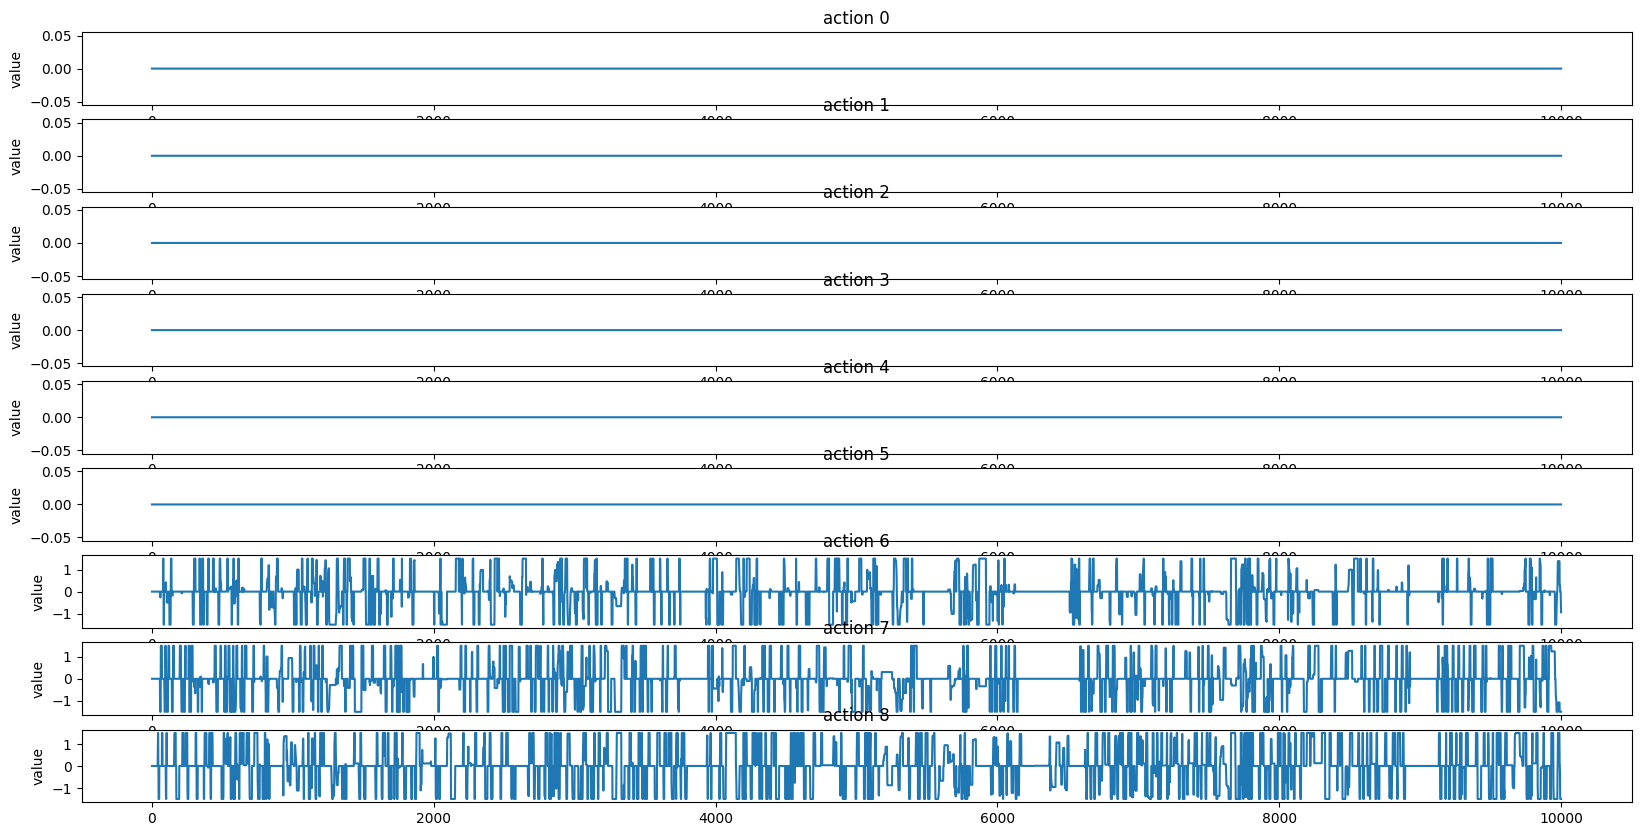

In [7]:
# import and plot actions

import pickle
import numpy as np
import matplotlib.pyplot as plt

file_name = "actions_ee_ori_action_traj_v1.pickle"

with open(file_name, "rb") as f:
    actions = pickle.load(f)

fig, axs = plt.subplots(9, 1, figsize=(20, 10))

for i in range(9):
    axs[i].plot(actions[:, i])
    axs[i].set_title("action " + str(i))
    axs[i].set_ylabel("value")

plt.show()

vx max:  0.3698466
vy max:  0.61692464
vtheta max:  1.1905228
eevx max:  0.75939584
eevy max:  1.1125308
eevz max:  0.6932879
eervx max:  0.76529706
eervy max:  1.7186493
eervz max:  1.8669701


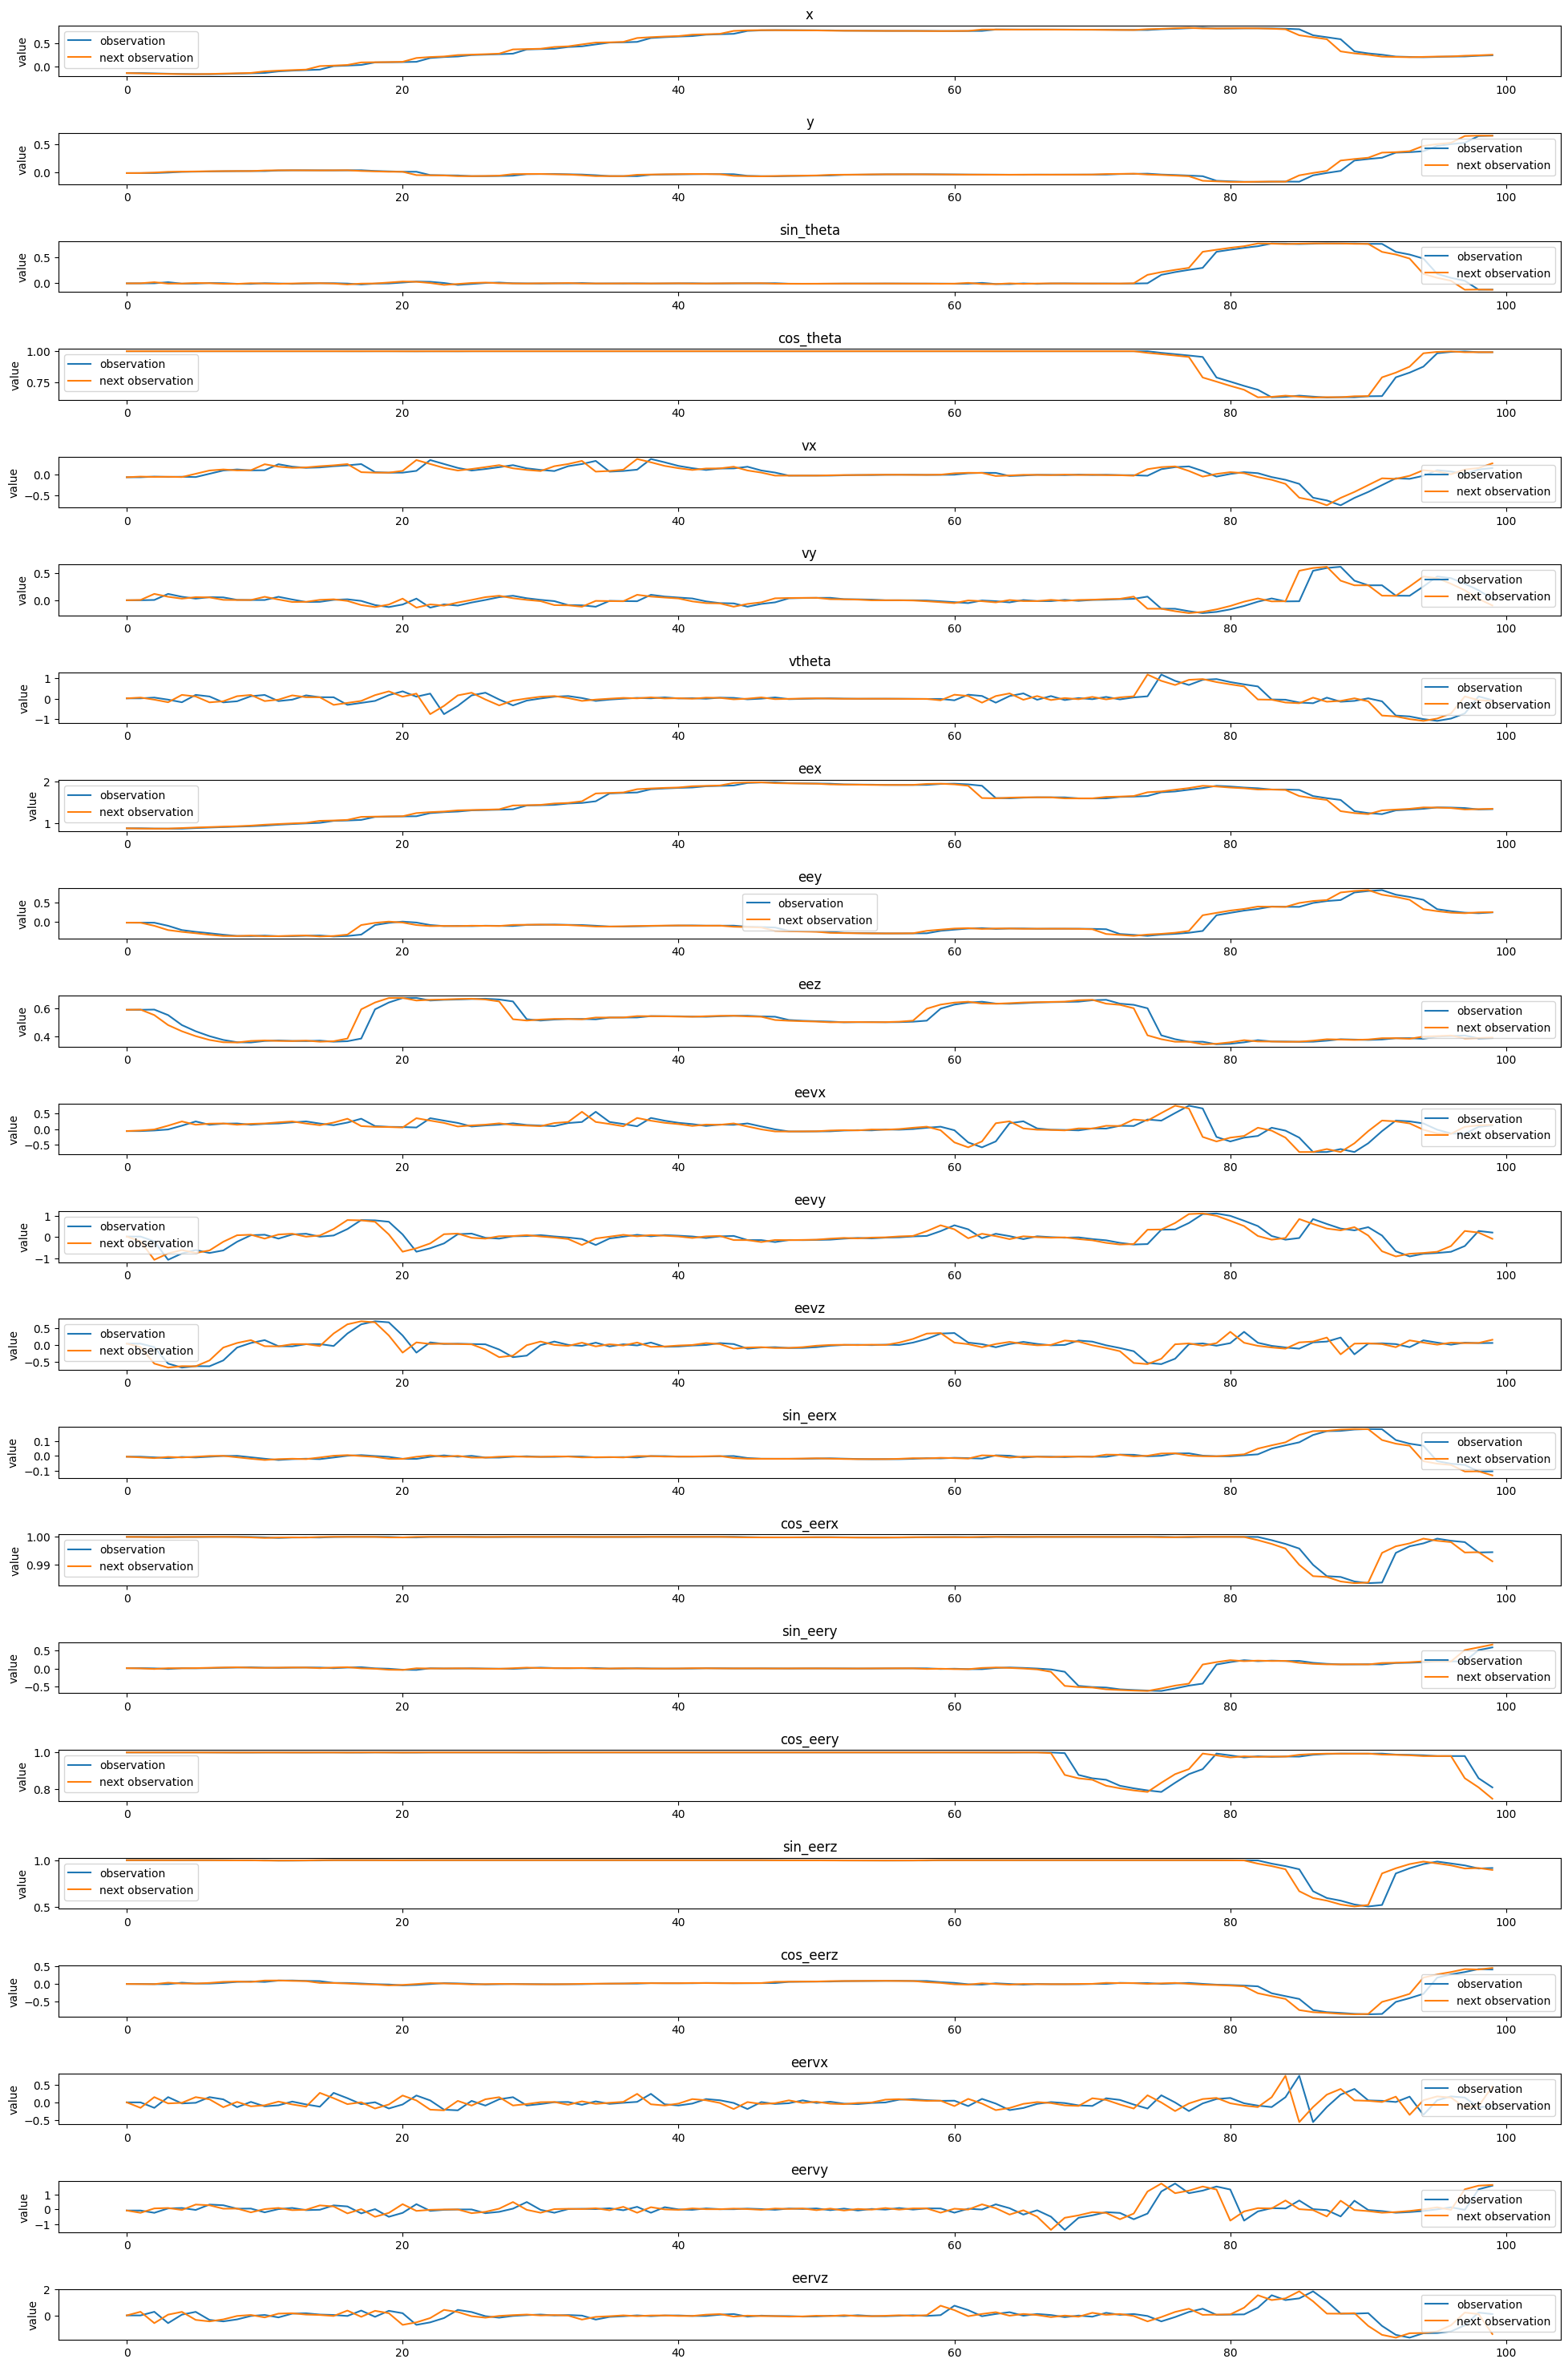

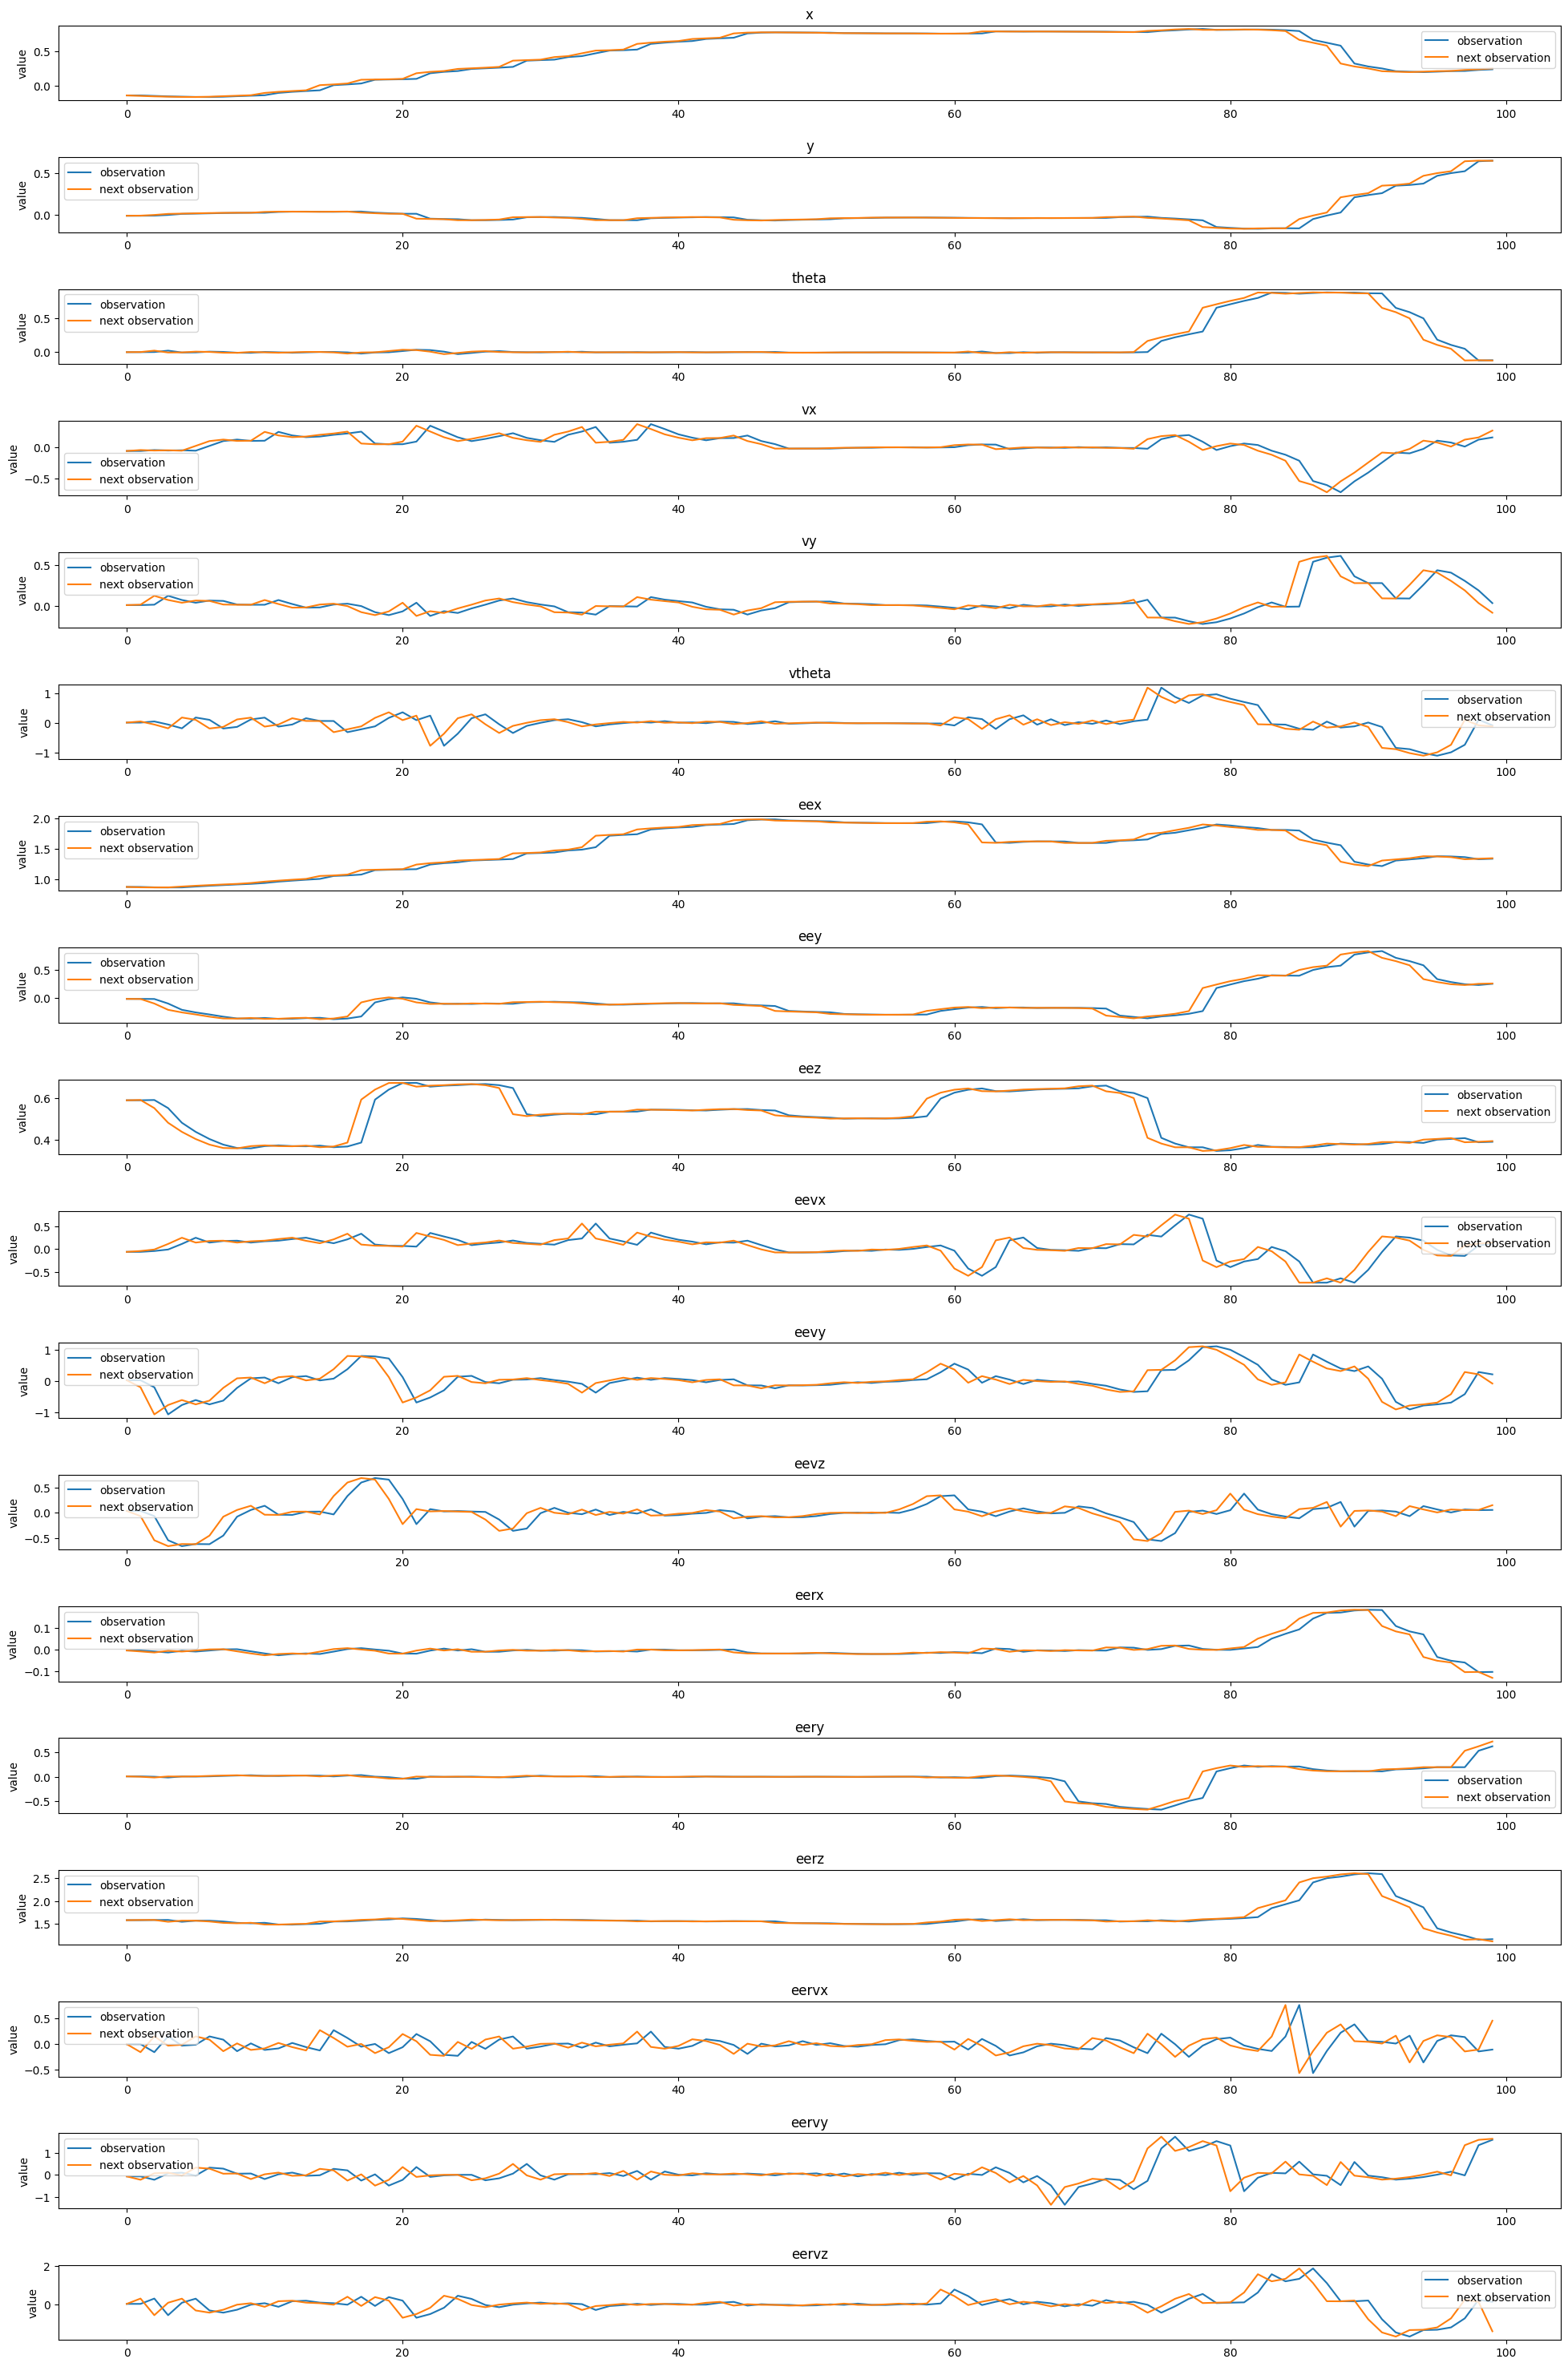

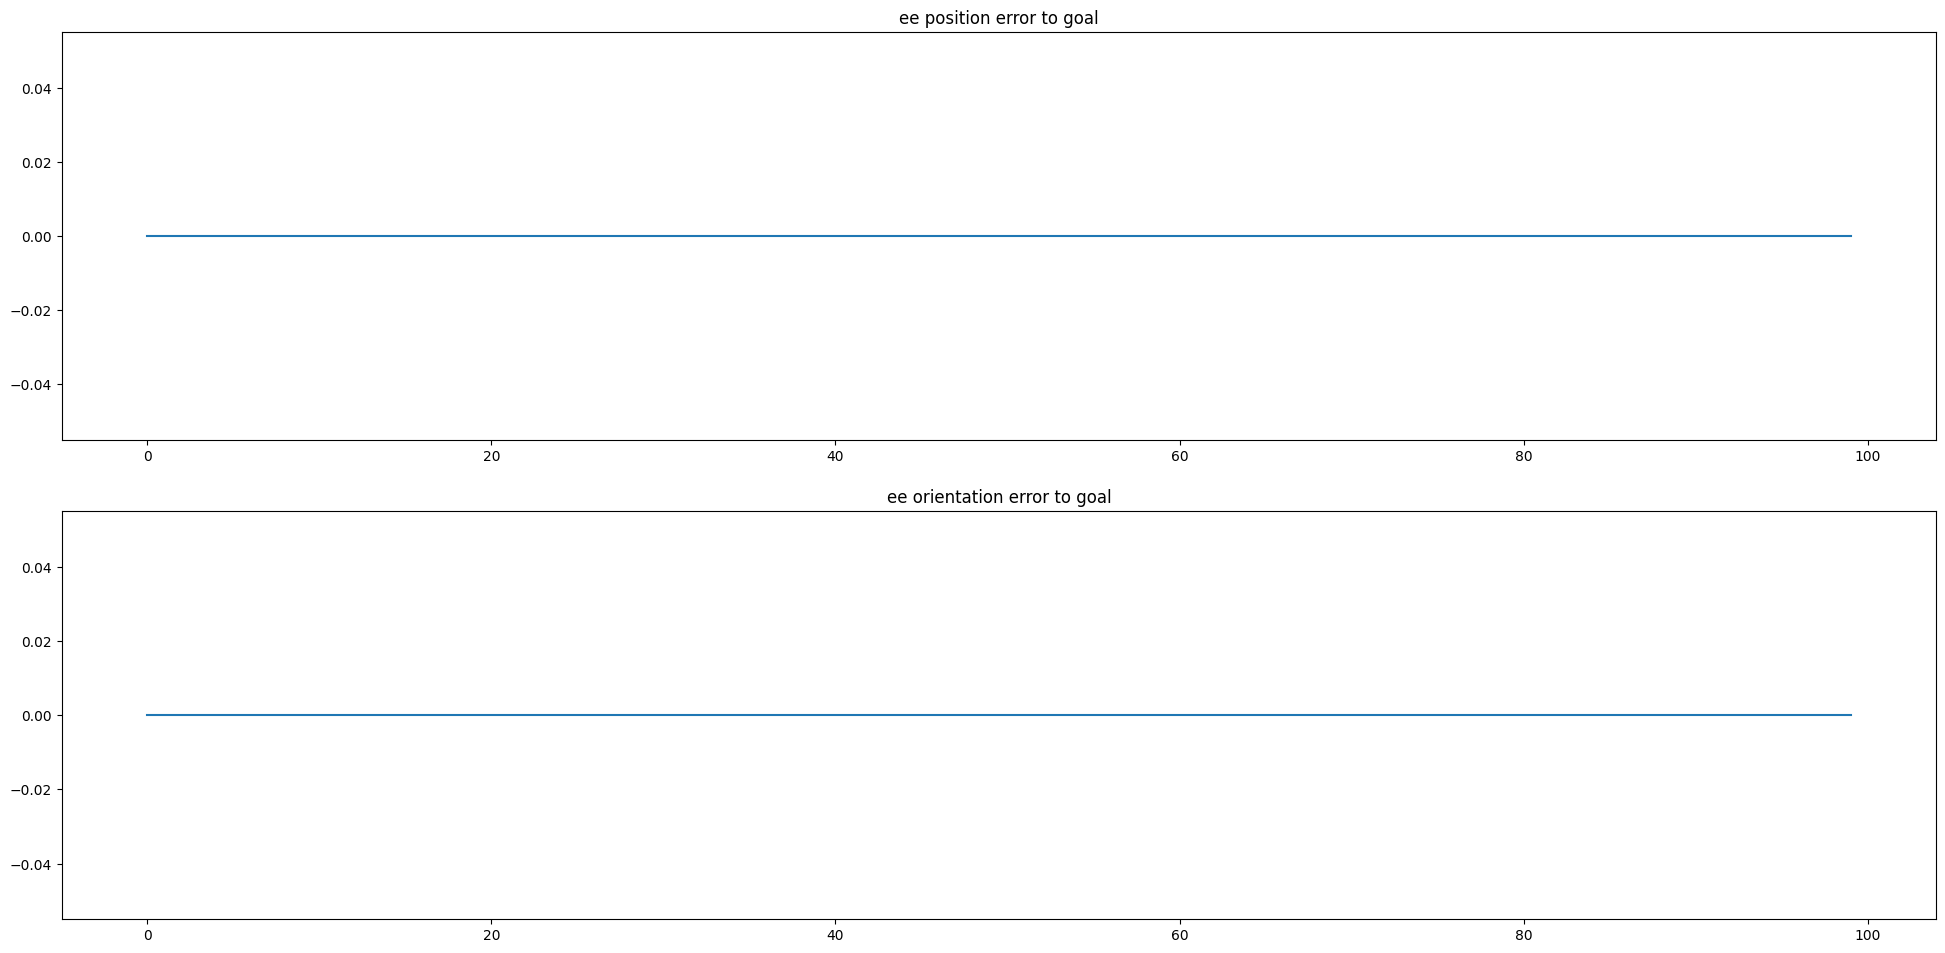

In [ ]:
"""Analyse data collected on real robot"""

import os
import pickle
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R


v0_ee_benchmark = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee_v1/brax_transitions_ee_ori_benchmark_odom_v0.pickle"
v1_ee_benchmark = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee_v1/brax_transitions_ee_ori_benchmark_odom_v1.pickle"
v0_ee_long = "/home/bhoffman/Documents/MT_FS24/simulation_transfer/data/test_data_spot_ee_v1/brax_transitions_ee_ori_long_odom_v0.pickle"

file_names = [v1_ee_benchmark]


# Define the state label dictionaries
state_label_dict = {
    0: "x",
    1: "y",
    2: "sin_theta",
    3: "cos_theta",
    4: "vx",
    5: "vy",
    6: "vtheta",
    7: "eex",
    8: "eey",
    9: "eez",
    10: "eevx",
    11: "eevy",
    12: "eevz",
    13: "sin_eerx",
    14: "cos_eerx",
    15: "sin_eery",
    16: "cos_eery",
    17: "sin_eerz",
    18: "cos_eerz",
    19: "eervx",
    20: "eervy",
    21: "eervz"
}

state_label_dict_cleaned = {
    0: "x",
    1: "y",
    2: "theta",
    3: "vx",
    4: "vy",
    5: "vtheta",
    6: "eex",
    7: "eey",
    8: "eez",
    9: "eevx",
    10: "eevy",
    11: "eevz",
    12: "eerx",
    13: "eery",
    14: "eerz",
    15: "eervx",
    16: "eervy",
    17: "eervz"
}

def load_data(file_names):
    data = []
    for file_name in file_names:
        with open(file_name, "rb") as f:
            data += pickle.load(f)
    return data

def transform_state_omega(states):
    sin_ee_rx = states[..., 13]
    cos_ee_rx = states[..., 14]
    sin_ee_ry = states[..., 15]
    cos_ee_ry = states[..., 16]
    sin_ee_rz = states[..., 17]
    cos_ee_rz = states[..., 18]
    roll = np.arctan2(sin_ee_rx, cos_ee_rx)
    pitch = np.arctan2(sin_ee_ry, cos_ee_ry)
    yaw = np.arctan2(sin_ee_rz, cos_ee_rz)
    rotations = R.from_euler('xyz', np.column_stack((roll, pitch, yaw)))
    omega_global = states[..., 19:22]
    omega_hand = rotations.inv().apply(omega_global)
    transformed_states = states.copy()
    transformed_states[..., 19:22] = omega_hand
    return transformed_states

data = load_data(file_names)

observations = np.array([d.observation for d in data])
actions = np.array([d.action for d in data])
next_observations = np.array([d.next_observation for d in data])


# next_observations = transform_state_omega(next_observations)
# observations = transform_state_omega(observations)


observations = observations[0:100]
actions = actions[0:100]
next_observations = next_observations[0:100]

plt.show()

print("vx max: ", np.max(observations[:, 4]))
print("vy max: ", np.max(observations[:, 5]))
print("vtheta max: ", np.max(observations[:, 6]))
print("eevx max: ", np.max(observations[:, 10]))
print("eevy max: ", np.max(observations[:, 11]))
print("eevz max: ", np.max(observations[:, 12]))
print("eervx max: ", np.max(observations[:, 19]))
print("eervy max: ", np.max(observations[:, 20]))
print("eervz max: ", np.max(observations[:, 21]))

n_plots = len(state_label_dict_cleaned)

# decode observations
theta = np.arctan2(observations[:, 2], observations[:, 3])
ee_rx = np.arctan2(observations[:, 13], observations[:, 14])
ee_ry = np.arctan2(observations[:, 15], observations[:, 16])
ee_rz = np.arctan2(observations[:, 17], observations[:, 18])

obsertvations_cleaned = np.zeros((observations.shape[0], n_plots))
obsertvations_cleaned[:, 0] = observations[:, 0]
obsertvations_cleaned[:, 1] = observations[:, 1]
obsertvations_cleaned[:, 2] = theta
obsertvations_cleaned[:, 3] = observations[:, 4]
obsertvations_cleaned[:, 4] = observations[:, 5]
obsertvations_cleaned[:, 5] = observations[:, 6]
obsertvations_cleaned[:, 6] = observations[:, 7]
obsertvations_cleaned[:, 7] = observations[:, 8]
obsertvations_cleaned[:, 8] = observations[:, 9]
obsertvations_cleaned[:, 9] = observations[:, 10]
obsertvations_cleaned[:, 10] = observations[:, 11]
obsertvations_cleaned[:, 11] = observations[:, 12]
obsertvations_cleaned[:, 12] = ee_rx
obsertvations_cleaned[:, 13] = ee_ry
obsertvations_cleaned[:, 14] = ee_rz
obsertvations_cleaned[:, 15] = observations[:, 19]
obsertvations_cleaned[:, 16] = observations[:, 20]
obsertvations_cleaned[:, 17] = observations[:, 21]

# decode next_observations
theta_next = np.arctan2(next_observations[:, 2], next_observations[:, 3])
ee_rx_next = np.arctan2(next_observations[:, 13], next_observations[:, 14])
ee_ry_next = np.arctan2(next_observations[:, 15], next_observations[:, 16])
ee_rz_next = np.arctan2(next_observations[:, 17], next_observations[:, 18])

next_obsertvations_cleaned = np.zeros((next_observations.shape[0], n_plots))
next_obsertvations_cleaned[:, 0] = next_observations[:, 0]
next_obsertvations_cleaned[:, 1] = next_observations[:, 1]
next_obsertvations_cleaned[:, 2] = theta_next
next_obsertvations_cleaned[:, 3] = next_observations[:, 4]
next_obsertvations_cleaned[:, 4] = next_observations[:, 5]
next_obsertvations_cleaned[:, 5] = next_observations[:, 6]
next_obsertvations_cleaned[:, 6] = next_observations[:, 7]
next_obsertvations_cleaned[:, 7] = next_observations[:, 8]
next_obsertvations_cleaned[:, 8] = next_observations[:, 9]
next_obsertvations_cleaned[:, 9] = next_observations[:, 10]
next_obsertvations_cleaned[:, 10] = next_observations[:, 11]
next_obsertvations_cleaned[:, 11] = next_observations[:, 12]
next_obsertvations_cleaned[:, 12] = ee_rx_next
next_obsertvations_cleaned[:, 13] = ee_ry_next
next_obsertvations_cleaned[:, 14] = ee_rz_next
next_obsertvations_cleaned[:, 15] = next_observations[:, 19]
next_obsertvations_cleaned[:, 16] = next_observations[:, 20]
next_obsertvations_cleaned[:, 17] = next_observations[:, 21]


# plot uncleaned
fig, axs = plt.subplots(len(state_label_dict), 1, figsize=(20, 30))
# add some space between subplots
fig.tight_layout(pad=3.0)

for i in range(len(state_label_dict)):
    axs[i].plot(observations[:, i], label="observation")
    axs[i].plot(next_observations[:, i], label="next observation")
    axs[i].set_title(state_label_dict[i])
    axs[i].set_ylabel("value")
    axs[i].legend()

plt.show()


fig, axs = plt.subplots(n_plots, 1, figsize=(20, 30))
# add some space between subplots
fig.tight_layout(pad=3.0)

for i in range(n_plots):
    axs[i].plot(obsertvations_cleaned[:, i], label="observation")
    axs[i].plot(next_obsertvations_cleaned[:, i], label="next observation")

    axs[i].set_title(state_label_dict_cleaned[i])
    axs[i].set_ylabel("value")
    axs[i].legend()

plt.show()

# set goal to always be the next observation
goal = next_obsertvations_cleaned


# plot error to goal for ee position and orientation
ee_pos = obsertvations_cleaned[:, 6:9]
ee_pos_goal = goal[:,6:9]
ee_pos_error = np.linalg.norm(ee_pos - ee_pos_goal, axis=1)

from scipy.spatial.transform import Rotation as R
ee_ori = obsertvations_cleaned[:, 12:15]
ee_ori_goal = goal[:, 12:15]
observed_rotation = R.from_euler("xyz", ee_ori, degrees=False)
goal_rotation = R.from_euler("xyz", ee_ori_goal, degrees=False)
relative_rotation = observed_rotation.inv() * goal_rotation
rotation_dist = relative_rotation.magnitude()

fig, axs = plt.subplots(2, 1, figsize=(20, 10))
# add some space between subplots
fig.tight_layout(pad=3.0)

axs[0].plot(ee_pos_error)
axs[0].set_title("ee position error to goal")

axs[1].plot(rotation_dist)
axs[1].set_title("ee orientation error to goal")

plt.show()


